<hr size=5 color='#002883'>

<p align="center"> <font size=7 color='#002883'> Elaboração de cartas sinóticas baseado no site de Ph.D. Alicia M. Bentley

<hr size=5 color='#002883'>

<p align="left"> <font size=5 color='#002883'> Professores:  

* Prof. Dra. Rita Yuri Ynoue

<p align="left"> <font size=5 color='#002883'> Monitor PAE:

* Ronald Guiuseppi Ramírez Nina [PhD. Candidate in Atmospheric Sciences]
* email: ronald.ramirez.nina@alumni.usp.br / ronald.ramirez.nina@usp.br

<hr size=5 color='#002883'>

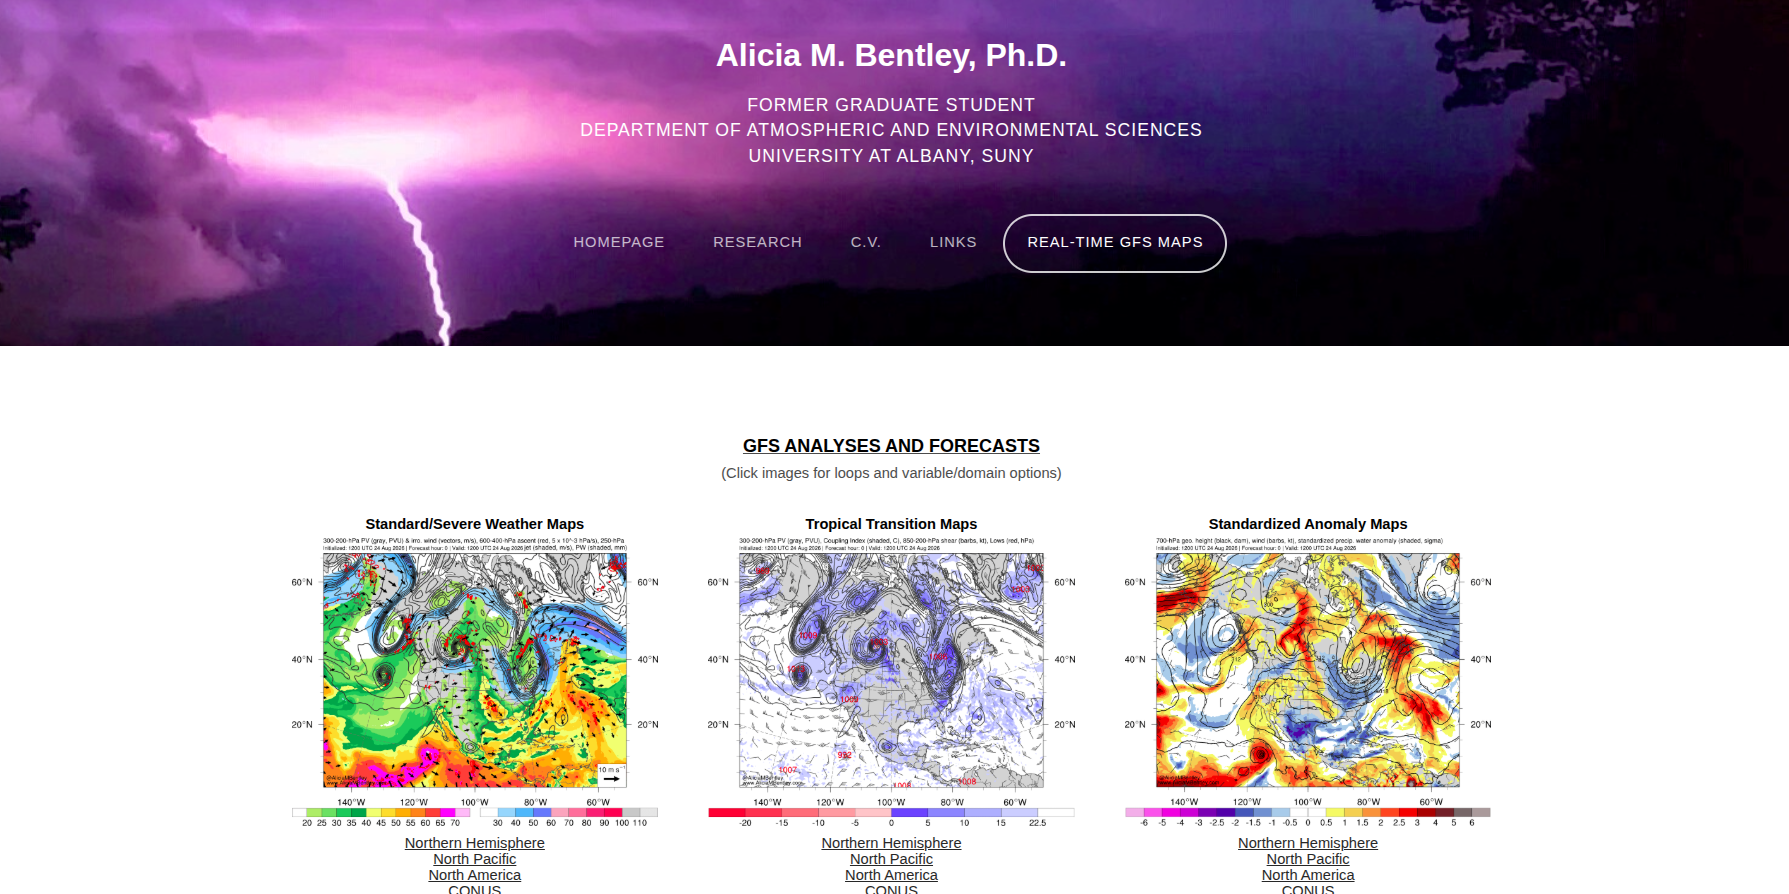

**Link:** https://www.atmos.albany.edu/student/abentley/realtime.html


<hr size=5 color='#002883'>

# <font size=6 color='#002883'> **1. preparação do Colab** <font>

<font size=4 color='#002883'> Executar as três células de abaixo: <font>

<font size=4 color='#002883'>1.1. Montar o drive para acesso a nossa pasta de trabalho <font>

In [1]:
# @title #### <font color='#002883'> Montar o drive para a importação da livraria utilities_new_version <font>
%%capture

from google.colab import drive
drive.mount('/content/drive')

<font size=4 color='#002883'>1.2. Adicionar o caminho do sistema para a importação do utilities_new_version.py <font>

In [2]:
# @title #### <font color='#002883'> Adicionar o caminho do Drive ao caminho do sistema para importação de módulos <font>
%%capture

import sys
sys.path.append('/content/drive/MyDrive/')

<font size=4 color='#002883'>1.3. Instaçaão de livrarias <font>

In [3]:
# @title #### <font color='#002883'> Instalar livrarias <font>
%%capture

!pip install imgaug
!pip install siphon

# Instalando a Biblioteca Pygrib
!pip install pygrib
#print('\n')

# Instalando a Biblioteca Cartopy
!pip install cartopy
!pip install shapely --no-binary shapely --force
#print('\n')

# Instalando a Biblioteca MetPy
!pip install "numpy<2.0" metpy --upgrade
#!pip install MetPy
#print('\n')

# Instalando a Biblioteca Boto3
!pip install boto3
#print('\n')

# Instalando a Biblioteca NetCDF4
!pip install netcdf4
#print('\n')

# Instalando a biblioteca para trabalhar arquivos .grib com a livraria xarray
!pip install -q cfgrib eccodes

# Instalando / atualizando a Biblioteca GDAL
!apt-add-repository -y ppa:ubuntugis/ubuntugis-unstable
!add-apt-repository -y ppa:ubuntugis/ppa
!apt-get install gdal-bin
!pip install 'gdal==3.0.4'
#print('\n')

# Install ImageMagick
!sudo apt install imagemagick
#print('\n')

<font size=4 color='#002883'>1.4. Reiniciar a sessão de trabalho. Necessário para a importação do módulo de Metpy <font>

In [ ]:
# @title #### <font color='#002883'> Reiniciar sessão devido ao modulo do Metpy <font>
%%capture

import os
os.kill(os.getpid(), 9)

<font size=4 color='#002883'> **2. Fazer downloand de arquivos complementários (e.g., shapefile de estados e provincias do Brasil e outros paises). Além disso, fazer o download do arquivo utilities.py para o uso no processamento de imagens de satélite da série GOES. Download do arquivo CPT para o realce do canal infravermelho e vapor d'água.** <font>

In [1]:
# @title #### <font color='#002883'> Baixar arquivos complementários <font>
%%capture

# Baixando o shapefile dos estados brasileiros
!wget -c https://geoftp.ibge.gov.br/organizacao_do_territorio/malhas_territoriais/malhas_municipais/municipio_2019/Brasil/BR/br_unidades_da_federacao.zip
#print('\n')

# Descomprimindo o arquivo de shapefile dos estados brasileiros
!unzip -o br_unidades_da_federacao.zip
#print('\n')

# Baixando o shapefile dos estados / províncias mundiais
!wget -c https://www.naturalearthdata.com/http//www.naturalearthdata.com/download/10m/cultural/ne_10m_admin_1_states_provinces.zip
#print('\n')

# Descomprimindo o arquivo de shapefile dos estados / províncias mundiais
!unzip -o ne_10m_admin_1_states_provinces.zip
#print('\n')

# Download da arquivo CPT exemplo (para realce de canais IR)
!wget -c https://www.dropbox.com/s/fdgnaqt91cy3x97/IR4AVHRR6.cpt
#print('\n')

# Download da arquivo CPT exemplo (para realce de canais WV)
!wget -c https://www.dropbox.com/s/4l9fys6pv5c68xk/SVGAWVX_TEMP.cpt
#print('\n')

<font size=4 color='#002883'> **3. Importar livrarias.** <font>

In [2]:
# @title #### <font color='#002883'> Importar livrarias para o processamento dos dados <font>
%%capture

from datetime import datetime
import os
import requests
import time as t
import sys

# Livrarias para leitura, processamento e plot de dados NetCDF
from netCDF4 import Dataset
from osgeo import gdal
import matplotlib.pyplot as plt
import cartopy, cartopy.crs as ccrs
import cartopy.io.shapereader as shpreader
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
from matplotlib import cm
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.dates import DateFormatter
import matplotlib as mpl
import matplotlib.colors as colors
import matplotlib.dates as mdates
import matplotlib.colors as mcolors

from datetime import timedelta, date, datetime
import pygrib
import numpy as np
import xarray as xr
gdal.PushErrorHandler('CPLQuietErrorHandler')

# Livrarias para o cálculo de campos meteorológicos
from metpy.units import units
import metpy.calc as mpcalc
import numpy.ma as ma

# Carregar a nova versão do utilities_new_version.py
#import sys
#folder_path = '/content/drive/MyDrive/USP-CURSOS/MONITORIA/METEOROLOGIA-SINOTICA-II-2026'
#if folder_path not in sys.path:
#    sys.path.append(folder_path)
#from utilities_new_version import download_CMI
#from utilities_new_version import reproject
#from utilities_new_version import loadCPT

<font size=4 color='red'> **4.1. Função para o download dos dados do modelo Global forecasting System (GFS).** <font>

In [3]:
# @title #### <font color='#002883'> Construir função para o download dos arquivos do GFS <font>
%%capture

# Link (select "grib filter" and check "Show the URL only for web programming" to verify the URL's):
# https://nomads.ncep.noaa.gov/

def download_gfs(date, iii):

    # Create the URL's based on the resolution
    if (resolution == '25'):
        url = 'https://nomads.ncep.noaa.gov/cgi-bin/filter_gfs_0p'+resolution+'.pl?file=gfs.t'+hour_run+'z.pgrb2.0p'+resolution+'.f'+str(hour).zfill(3)+'&all_lev=on&all_var=on&subregion=&leftlon='+min_lon+'&rightlon='+max_lon+'&toplat='+max_lat+'&bottomlat='+min_lat+'&dir=%2Fgfs.'+date+'%2F'+hour_run+'%2Fatmos'
        file_name = 'gfs.t'+hour_run+'z.pgrb2.0p'+resolution+'.f'+str(hour).zfill(3)
        res = 'prgb2.0p'+resolution+'.f'
    elif (resolution == '50'):
        url = 'https://nomads.ncep.noaa.gov/cgi-bin/filter_gfs_0p'+resolution+'.pl?file=gfs.t'+hour_run+'z.pgrb2full.0p'+resolution+'.f'+str(hour).zfill(3)+'&all_lev=on&all_var=on&subregion=&leftlon='+min_lon+'&rightlon='+max_lon+'&toplat='+max_lat+'&bottomlat='+min_lat+'&dir=%2Fgfs.'+date+'%2F'+hour_run+'%2Fatmos'
        file_name = 'gfs.t'+hour_run+'z.pgrb2.0p'+resolution+'.f'+str(hour).zfill(3)
        res = 'prgb2.0p'+resolution+'.f'
    elif (resolution == '1'):
        url = 'https://nomads.ncep.noaa.gov/cgi-bin/filter_gfs_'+resolution+'p00.pl?file=gfs.t'+hour_run+'z.pgrb2.'+resolution+'p00.f'+str(hour).zfill(3)+'&all_lev=on&all_var=on&subregion=&leftlon='+min_lon+'&rightlon='+max_lon+'&toplat='+max_lat+'&bottomlat='+min_lat+'&dir=%2Fgfs.'+date+'%2F'+hour_run+'%2Fatmos'
        file_name = 'gfs.t'+hour_run+'z.pgrb2.'+resolution+'p00.f'+str(hour).zfill(3)
        res = 'prgb2.'+resolution+'p00.f'

    # Print the file name
    print("File name: ", file_name)
    # Sends a GET request to the specified url
    myfile = requests.get(url)

    # Download the file
    open(dir + '//' + file_name, 'wb').write(myfile.content)

<font size=4 color='red'> **4.2. Função para o download de dados do Geostationary Operational Environmental Satellite - 19 (GOES-19) do Amazon Web Services (AWS).** <font>

In [4]:
# @title #### <font color='#002883'> Construir função para o download dos arquivos do GOES-19 <font>
%%capture

# ==========================================================================================================
# Training: Python and GOES-19 Imagery: Functions for download data from AWS
# ==========================================================================================================
# Required modules
import os                                # Miscellaneous operating system interfaces
import numpy as np                       # Import the Numpy package
import colorsys                          # To make convertion of colormaps
import boto3                             # Amazon Web Services (AWS) SDK for Python
from botocore import UNSIGNED            # boto3 config
from botocore.config import Config       # boto3 config
import math                              # Mathematical functions
from datetime import datetime            # Basic Dates and time types
from osgeo import osr                    # Python bindings for GDAL
from osgeo import gdal                   # Python bindings for GDAL

#from netCDF4 import Dataset          # Read / Write NetCDF4 files
#import matplotlib.pyplot as plt      # Plotting library
#import cartopy, cartopy.crs as ccrs  # Plot maps
##import sys
#from datetime import timedelta, date, datetime   # Manipulate dates

# ==========================================================================================================
def loadCPT(path):

    try:
        f = open(path)
    except:
        print ("File ", path, "not found")
        return None

    lines = f.readlines()

    f.close()

    x = np.array([])
    r = np.array([])
    g = np.array([])
    b = np.array([])

    colorModel = 'RGB'

    for l in lines:
        ls = l.split()
        if l[0] == '#':
            if ls[-1] == 'HSV':
                colorModel = 'HSV'
                continue
            else:
                continue
        if ls[0] == 'B' or ls[0] == 'F' or ls[0] == 'N':
            pass
        else:
            x=np.append(x,float(ls[0]))
            r=np.append(r,float(ls[1]))
            g=np.append(g,float(ls[2]))
            b=np.append(b,float(ls[3]))
            xtemp = float(ls[4])
            rtemp = float(ls[5])
            gtemp = float(ls[6])
            btemp = float(ls[7])

        x=np.append(x,xtemp)
        r=np.append(r,rtemp)
        g=np.append(g,gtemp)
        b=np.append(b,btemp)

    if colorModel == 'HSV':
        for i in range(r.shape[0]):
            rr, gg, bb = colorsys.hsv_to_rgb(r[i]/360.,g[i],b[i])
        r[i] = rr ; g[i] = gg ; b[i] = bb

    if colorModel == 'RGB':
        r = r/255.0
        g = g/255.0
        b = b/255.0

    xNorm = (x - x[0])/(x[-1] - x[0])

    red   = []
    blue  = []
    green = []

    for i in range(len(x)):
        red.append([xNorm[i],r[i],r[i]])
        green.append([xNorm[i],g[i],g[i]])
        blue.append([xNorm[i],b[i],b[i]])

    colorDict = {'red': red, 'green': green, 'blue': blue}

    return colorDict

# ==========================================================================================================

def download_CMI(yyyymmddhhmn, band, path_dest):

    os.makedirs(path_dest, exist_ok=True)

    year = datetime.strptime(yyyymmddhhmn, "%Y%m%d%H%M").strftime("%Y")
    day_of_year = datetime.strptime(yyyymmddhhmn, "%Y%m%d%H%M").strftime("%j")
    hour = datetime.strptime(yyyymmddhhmn, "%Y%m%d%H%M").strftime("%H")
    min = datetime.strptime(yyyymmddhhmn, "%Y%m%d%H%M").strftime("%M")

    # AMAZON repository information (MUDADO PARA GOES-19)
    bucket_name = "noaa-goes19"
    product_name = "ABI-L2-CMIPF"

    # Initializes the S3 client
    s3_client = boto3.client("s3", config=Config(signature_version=UNSIGNED))

    # File structure (MUDADO PARA _G19_)
    prefix = f"{product_name}/{year}/{day_of_year}/{hour}/OR_{product_name}-M6C{int(band):02.0f}_G19_s{year}{day_of_year}{hour}{min}"

    # Search for the file on the server
    s3_result = s3_client.list_objects_v2(
        Bucket=bucket_name, Prefix=prefix, Delimiter="/"
    )

    if "Contents" not in s3_result:
        print(f"No files found for the date: {yyyymmddhhmn}, Band-{band}")
        return -1
    else:
        for obj in s3_result["Contents"]:
            key = obj["Key"]
            file_name = key.split("/")[-1].split(".")[0]

            if os.path.exists(f"{path_dest}/{file_name}.nc"):
                print(f"File {path_dest}/{file_name}.nc exists")
            else:
                print(f"Downloading file {path_dest}/{file_name}.nc")
                s3_client.download_file(
                    bucket_name, key, f"{path_dest}/{file_name}.nc"
                )
    return f"{file_name}"

# ==========================================================================================================
def download_PROD(yyyymmddhhmn, product_name, path_dest):

    os.makedirs(path_dest, exist_ok=True)

    year = datetime.strptime(yyyymmddhhmn, "%Y%m%d%H%M").strftime("%Y")
    day_of_year = datetime.strptime(yyyymmddhhmn, "%Y%m%d%H%M").strftime("%j")
    hour = datetime.strptime(yyyymmddhhmn, "%Y%m%d%H%M").strftime("%H")
    min = datetime.strptime(yyyymmddhhmn, "%Y%m%d%H%M").strftime("%M")

    # AMAZON repository information (MUDADO PARA GOES-19)
    bucket_name = "noaa-goes19"

    s3_client = boto3.client("s3", config=Config(signature_version=UNSIGNED))

    # File structure (MUDADO PARA _G19_)
    prefix = f"{product_name}/{year}/{day_of_year}/{hour}/OR_{product_name}-M6_G19_s{year}{day_of_year}{hour}{min}"

    s3_result = s3_client.list_objects_v2(
        Bucket=bucket_name, Prefix=prefix, Delimiter="/"
    )

    if "Contents" not in s3_result:
        print(f"No files found for the date: {yyyymmddhhmn}, Product-{product_name}")
        return -1
    else:
        for obj in s3_result["Contents"]:
            key = obj["Key"]
            file_name = key.split("/")[-1].split(".")[0]

            if os.path.exists(f"{path_dest}/{file_name}.nc"):
                print(f"File {path_dest}/{file_name}.nc exists")
            else:
                print(f"Downloading file {path_dest}/{file_name}.nc")
                s3_client.download_file(
                    bucket_name, key, f"{path_dest}/{file_name}.nc"
                )
    return f"{file_name}"

# ==========================================================================================================
def download_GLM(yyyymmddhhmnss, path_dest):

    os.makedirs(path_dest, exist_ok=True)

    year = datetime.strptime(yyyymmddhhmnss, "%Y%m%d%H%M%S").strftime("%Y")
    day_of_year = datetime.strptime(yyyymmddhhmnss, "%Y%m%d%H%M%S").strftime("%j")
    hour = datetime.strptime(yyyymmddhhmnss, "%Y%m%d%H%M%S").strftime("%H")
    min = datetime.strptime(yyyymmddhhmnss, "%Y%m%d%H%M%S").strftime("%M")
    seg = datetime.strptime(yyyymmddhhmnss, "%Y%m%d%H%M%S").strftime("%S")

    # AMAZON repository information (MUDADO PARA GOES-19)
    bucket_name = "noaa-goes19"

    s3_client = boto3.client("s3", config=Config(signature_version=UNSIGNED))

    product_name = "GLM-L2-LCFA"
    # File structure (MUDADO PARA _G19_)
    prefix = f"{product_name}/{year}/{day_of_year}/{hour}/OR_{product_name}_G19_s{year}{day_of_year}{hour}{min}{seg}"

    s3_result = s3_client.list_objects_v2(
        Bucket=bucket_name, Prefix=prefix, Delimiter="/"
    )

    if "Contents" not in s3_result:
        print(f"No files found for the date: {yyyymmddhhmnss}, Product-{product_name}")
        return -1
    else:
        for obj in s3_result["Contents"]:
            key = obj["Key"]
            file_name = key.split("/")[-1].split(".")[0]

            if os.path.exists(f"{path_dest}/{file_name}.nc"):
                print(f"File {path_dest}/{file_name}.nc exists")
            else:
                print(f"Downloading file {path_dest}/{file_name}.nc")
                s3_client.download_file(
                    bucket_name, key, f"{path_dest}/{file_name}.nc"
                )
    return f"{file_name}"

# ==========================================================================================================
# Function to convert lat / lon extent to GOES-19 extents
def convertExtent2GOESProjection(extent):
    GOES19_HEIGHT = 35786023.0
    # Longitude de sub-satélite do GOES-19 (GOES-East operacional)
    GOES19_LONGITUDE = -75.2

    a, b = latlon2xy(extent[1], extent[0])
    c, d = latlon2xy(extent[3], extent[2])
    return (a * GOES19_HEIGHT, c * GOES19_HEIGHT, b * GOES19_HEIGHT, d * GOES19_HEIGHT)

# ==========================================================================================================
# Functions to convert lat / lon extent to array indices
def geo2grid(lat, lon, nc):

    # Apply scale and offset
    xscale, xoffset = nc.variables['x'].scale_factor, nc.variables['x'].add_offset
    yscale, yoffset = nc.variables['y'].scale_factor, nc.variables['y'].add_offset

    x, y = latlon2xy(lat, lon)
    col = (x - xoffset)/xscale
    lin = (y - yoffset)/yscale
    return int(lin), int(col)

# ==========================================================================================================
def latlon2xy(lat, lon):
    # goes_imagery_projection:semi_major_axis
    req = 6378137 # meters
    #  goes_imagery_projection:inverse_flattening
    invf = 298.257222096
    # goes_imagery_projection:semi_minor_axis
    rpol = 6356752.31414 # meters
    e = 0.0818191910435
    # goes_imagery_projection:perspective_point_height + goes_imagery_projection:semi_major_axis
    H = 42164160 # meters
    # goes_imagery_projection: longitude_of_projection_origin
    lambda0 = -1.308996939

    # Convert to radians
    latRad = lat * (math.pi/180)
    lonRad = lon * (math.pi/180)

    # (1) geocentric latitude
    Phi_c = math.atan(((rpol * rpol)/(req * req)) * math.tan(latRad))
    # (2) geocentric distance to the point on the ellipsoid
    rc = rpol/(math.sqrt(1 - ((e * e) * (math.cos(Phi_c) * math.cos(Phi_c)))))
    # (3) sx
    sx = H - (rc * math.cos(Phi_c) * math.cos(lonRad - lambda0))
    # (4) sy
    sy = -rc * math.cos(Phi_c) * math.sin(lonRad - lambda0)
    # (5)
    sz = rc * math.sin(Phi_c)

    # x,y
    x = math.asin((-sy)/math.sqrt((sx*sx) + (sy*sy) + (sz*sz)))
    y = math.atan(sz/sx)

    return x, y

# ==========================================================================================================
# Function to reproject the data
def reproject(file_name, ncfile, array, extent, undef):

    # Read the original file projection and configure the output projection
    source_prj = osr.SpatialReference()
    source_prj.ImportFromProj4(ncfile.GetProjectionRef())

    target_prj = osr.SpatialReference()
    target_prj.ImportFromProj4("+proj=longlat +ellps=WGS84 +datum=WGS84 +no_defs")

    # Reproject the data
    GeoT = ncfile.GetGeoTransform()
    driver = gdal.GetDriverByName('MEM')
    raw = driver.Create('raw', array.shape[0], array.shape[1], 1, gdal.GDT_Float32)
    raw.SetGeoTransform(GeoT)
    raw.GetRasterBand(1).WriteArray(array)

    # Define the parameters of the output file
    kwargs = {'format': 'netCDF', \
            'srcSRS': source_prj, \
            'dstSRS': target_prj, \
            'outputBounds': (extent[0], extent[3], extent[2], extent[1]), \
            'outputBoundsSRS': target_prj, \
            'outputType': gdal.GDT_Float32, \
            'srcNodata': undef, \
            'dstNodata': 'nan', \
            'resampleAlg': gdal.GRA_NearestNeighbour}

    # Write the reprojected file on disk
    gdal.Warp(file_name, raw, **kwargs)


<font size=4 color='#002883'> **5. Download dos dados do modelo Global forecasting System (GFS). É necessário editar a data Year = YYYY, month = mm, day = dd e hour = hh. Os dados do GFS só estão disponíveis até 5 dias atrás da data atual.** <font>

In [9]:
# @title #### <font color='#002883'> Download dos dados do GFS <font>
#%%capture

# Configurar a data de acesso aos dados do GFS
year = 2026
month = 9
day = 4
hour = 00

# Extensão desejada - COLOCAR AQUI ENTRE ASPAS POIS É UMA STRING
# longitude de -180 a 180
min_lon = '-122.50'
max_lon = '12.50'
min_lat = '-80.0'
max_lat = '25.0'

print('---------------------------------------')
print('GFS Download (NOMADS) - Script started.')
print('---------------------------------------')

# Start the time counter
start_time = t.time()

# Data desejada (Únicamente os últimos 10 dias!): Formato - 'YYYY, MM, DD, HH'
dt = datetime(year, month, day, hour)
yyyymmddhhmn = (f'{dt:%Y%m%d%H}00') # Data e hora da imagem de satélite

#-----------------------------------------------------------------------------------------------------------

# Download diretório
dir = "Samples"; os.makedirs(dir, exist_ok=True)

# Data desajada (Únicamente os últimos 10 dias!): Formato - 'YYYYMMDD'
date = (f'{dt:%Y%m%d}')

# Resolução espacial desejada: '25' or '50' or '1'
resolution = '25' #'1'

# Hora de execução: '00' or '06' or '12' or '18'
#hour_run = '00'
hour_run=(f'{dt:%H}')

# Horas de previsão
hour_ini = 0  # Init time
hour_end = 0 # End time
hour_int = 3  # Interval

if (resolution == '25'):
  res = 'pgrb2.0p'+resolution+'.f'
elif (resolution == '50'):
  res = 'pgrb2.0p'+resolution+'.f'
elif (resolution == '1'):
  res = 'pgrb2.'+resolution+'p00.f'

#-----------------------------------------------------------------------------------------------------------

# Download loop
for hour in range(hour_ini, hour_end + 1, hour_int):
    print('\n---------------------')
    print('Downloading GFS File:')
    print('---------------------')
    print('Resolution: ' + resolution)
    print('Date: ' + date)
    print('Run: ' + hour_run)
    print('Forecast Hour: f' + str(hour).zfill(3))
    # Call the download function
    download_gfs(date,hour)

# End the time counter
print('\nTotal Processing Time:', round((t.time() - start_time),2), 'seconds.')

---------------------------------------
GFS Download (NOMADS) - Script started.
---------------------------------------

---------------------
---------------------
Resolution: 25
Date: 20260904
Run: 00
Forecast Hour: f000
File name:  gfs.t00z.pgrb2.0p25.f000

Total Processing Time: 22.86 seconds.


<font size=4 color='#002883'> **6. Download dos dados de satélite do GOES-19.** <font>

In [10]:
# @title #### <font color='#002883'> Download de GOES-19 <font>
#%%capture

# Seleção da extensão [min. lon, min. lat, max. lon, max. lat]
# Lembrar que longitude está definida entre -180 e 180
extent = [float(min_lon), float(min_lat), float(max_lon), float(max_lat)]

# Input e output directorios
input = "/content/Samples"; os.makedirs(input, exist_ok=True)
output = "/content/Output"; os.makedirs(output, exist_ok=True)

#-----------------------------------------------------------------------------------------------------------
date = (f'{dt:%Y%m%d}')
yyyymmddhhmn = (f'{dt:%Y%m%d%H}00') # Data e hora da imagem de satélite
hour_run=(f'{dt:%H}')

# Download the ABI file channel 13 - Clean IR
file_ir = download_CMI(yyyymmddhhmn, 13, input)

# Variable
var = 'CMI'
# Abrir o dado
img = gdal.Open(f'NETCDF:{input}/{file_ir}.nc:' + var)

# Ler os metadados
metadata = img.GetMetadata()
scale = float(metadata.get(var + '#scale_factor'))
offset = float(metadata.get(var + '#add_offset'))
undef = float(metadata.get(var + '#_FillValue'))
dtime = metadata.get('NC_GLOBAL#time_coverage_start')

# Carregar os dados
ds_cmi = img.ReadAsArray(0, 0, img.RasterXSize, img.RasterYSize).astype(float)

# Aplicar a escala, offset e converter de Kelvin para Graus Celcius
ds_cmi = (ds_cmi * scale + offset) - 273.15

# Reprojeção do arquivo
filename_ret = f'{output}/IR_{yyyymmddhhmn}.nc'
reproject(filename_ret, img, ds_cmi, extent, undef)

# Ler a imagem do GOES-19 reprojetada
file = Dataset(filename_ret)

# Acessar aos valores dos pixel
data = file.variables['Band1'][:]

<font size=4 color='#002883'> **7. Definir os campos meteorológicos por níveis do GFS.** <font>

In [38]:
# @title #### <font color='#002883'> Definir as variáveis do GFS por níveis <font>
%%capture

# Ler o dado grib do GFS
grib = pygrib.open(f'Samples/gfs.t{hour_run}z.{res}000')

# Selecionar a variável
mslp = grib.select(name='Pressure reduced to MSL')[0]

# Acessar informação do arquivo
init  = str(mslp.analDate)      # Init date / time
run   = str(mslp.hour).zfill(2) # Run
ftime = str(mslp.forecastTime)  # Forecast hour
valid = str(mslp.validDate)     # Valid date / time
print('Init: ' + init + ' UTC')
print('Run: ' + run + 'Z')
print('Forecast: +' + ftime)
print('Valid: ' + valid + ' UTC')

# ========================================================================
# VARIÁVEIS DE SUPERFÍCIE:
# - Pressão reduzida ao nível medio do mar
# - Taxa de precipitação
#
# VARIÁVEL DE TODA A COLUNA ATMOSFÉRICA:
# - Água precipitável
# ========================================================================
# Ler a data da região específica
# Longitude tem que estar entre 0 e 360 graus
mslp, lats, lons = mslp.data(lat1=extent[1],lat2=extent[3],lon1=extent[0],lon2=extent[2])
# Converter para hPa
mslp = mslp / 100

# Selecionar a variável
prtwt = grib.select(name='Precipitable water')[0]
prtwt = prtwt.data(lat1=extent[1],lat2=extent[3],lon1=extent[0],lon2=extent[2])[0]
# Quero somente valores maiores que 0
mask_prtwt = ma.masked_less(prtwt, 0).mask
prtwt[mask_prtwt] = np.nan

# Busca a variável de taxa de precipitação na superfície
precip_rate = grib.select(name='Precipitation rate', typeOfLevel='surface')[0]

# ========================================================================
# ALTURA GEOPOTENCIAL
# ========================================================================
# Select the variable
hght_1000 = grib.select(name='Geopotential height', typeOfLevel = 'isobaricInhPa', level = 1000)[0]
# Read the data for a specific region
hght_1000 = hght_1000.data(lat1=extent[1],lat2=extent[3],lon1=extent[0],lon2=extent[2])[0]

# Select the variable
hght_850 = grib.select(name='Geopotential height', typeOfLevel = 'isobaricInhPa', level = 850)[0]
# Read the data for a specific region
hght_850 = hght_850.data(lat1=extent[1],lat2=extent[3],lon1=extent[0],lon2=extent[2])[0]

# Select the variable
hght_700 = grib.select(name='Geopotential height', typeOfLevel = 'isobaricInhPa', level = 700)[0]
# Read the data for a specific region
hght_700 = hght_700.data(lat1=extent[1],lat2=extent[3],lon1=extent[0],lon2=extent[2])[0]

# Select the variable
hght_500 = grib.select(name='Geopotential height', typeOfLevel = 'isobaricInhPa', level = 500)[0]
# Read the data for a specific region
hght_500 = hght_500.data(lat1=extent[1],lat2=extent[3],lon1=extent[0],lon2=extent[2])[0]

# Select the variable
hght_250 = grib.select(name='Geopotential height', typeOfLevel = 'isobaricInhPa', level = 250)[0]
# Read the data for a specific region
hght_250 = hght_250.data(lat1=extent[1],lat2=extent[3],lon1=extent[0],lon2=extent[2])[0]

# ========================================================================
# ESPESSURA
# ========================================================================
# Calculate and smooth 1000-500 hPa thickness
thickness_1000_500 = hght_500 - hght_1000
# Calculate and smooth 1000-850 hPa thickness
thickness_1000_850 = hght_850 - hght_1000

# ========================================================================
# COMPONENTES ZONAL (U) E MERIDIONAL (V) DO VENTO
# ========================================================================
# Select the variable
u_1000 = grib.select(name='U component of wind', typeOfLevel = 'isobaricInhPa', level = 1000)[0]
# Read the data for a specific region
u_1000, lats, lons = u_1000.data(lat1=extent[1],lat2=extent[3],lon1=extent[0],lon2=extent[2])
# Select the variable
v_1000 = grib.select(name='V component of wind', typeOfLevel = 'isobaricInhPa', level = 1000)[0]
# Read the data for a specific region
v_1000 = v_1000.data(lat1=extent[1],lat2=extent[3],lon1=extent[0],lon2=extent[2])[0]

# Selecionar a variável
u_925 = grib.select(name='U component of wind', typeOfLevel = 'isobaricInhPa', level = 925)[0]
# Ler a data para a região específica
u_925, lats, lons = u_925.data(lat1=extent[1],lat2=extent[3],lon1=extent[0],lon2=extent[2])
# Selecionar a variável
v_925 = grib.select(name='V component of wind', typeOfLevel = 'isobaricInhPa', level = 925)[0]
# Ler a data para a região específica
v_925 = v_925.data(lat1=extent[1],lat2=extent[3],lon1=extent[0],lon2=extent[2])[0]

# Select the variable
u_850 = grib.select(name='U component of wind', typeOfLevel = 'isobaricInhPa', level = 850)[0]
# Read the data for a specific region
u_850, lats, lons = u_850.data(lat1=extent[1],lat2=extent[3],lon1=extent[0],lon2=extent[2])
# Select the variable
v_850 = grib.select(name='V component of wind', typeOfLevel = 'isobaricInhPa', level = 850)[0]
# Read the data for a specific region
v_850 = v_850.data(lat1=extent[1],lat2=extent[3],lon1=extent[0],lon2=extent[2])[0]

# Select the variable
u_700 = grib.select(name='U component of wind', typeOfLevel = 'isobaricInhPa', level = 700)[0]
# Read the data for a specific region
u_700, lats, lons = u_700.data(lat1=extent[1],lat2=extent[3],lon1=extent[0],lon2=extent[2])
# Select the variable
v_700 = grib.select(name='V component of wind', typeOfLevel = 'isobaricInhPa', level = 700)[0]
# Read the data for a specific region
v_700 = v_700.data(lat1=extent[1],lat2=extent[3],lon1=extent[0],lon2=extent[2])[0]

# Select the variable
u_500 = grib.select(name='U component of wind', typeOfLevel = 'isobaricInhPa', level = 500)[0]
# Read the data for a specific region
u_500, lats, lons = u_500.data(lat1=extent[1],lat2=extent[3],lon1=extent[0],lon2=extent[2])
# Select the variable
v_500 = grib.select(name='V component of wind', typeOfLevel = 'isobaricInhPa', level = 500)[0]
# Read the data for a specific region
v_500 = v_500.data(lat1=extent[1],lat2=extent[3],lon1=extent[0],lon2=extent[2])[0]

# Selecionar a variável
u_250 = grib.select(name='U component of wind', typeOfLevel = 'isobaricInhPa', level = 250)[0]
# Ler a data para a região específica
u_250, lats, lons = u_250.data(lat1=extent[1],lat2=extent[3],lon1=extent[0],lon2=extent[2])
# Selecionar a variável
v_250 = grib.select(name='V component of wind', typeOfLevel = 'isobaricInhPa', level = 250)[0]
# Ler a data para a região específica
v_250 = v_250.data(lat1=extent[1],lat2=extent[3],lon1=extent[0],lon2=extent[2])[0]

# ========================================================================
# OMEGA
# ========================================================================
# Selecionar a variável
w_850 = grib.select(name='Vertical velocity', typeOfLevel = 'isobaricInhPa', level = 850)[0]
# Ler a data para a região específica
w_850 = w_850.data(lat1=extent[1],lat2=extent[3],lon1=extent[0],lon2=extent[2])[0]
# Selecionar a variável
w_500 = grib.select(name='Vertical velocity', typeOfLevel = 'isobaricInhPa', level = 500)[0]
# Ler a data para a região específica
w_500 = w_500.data(lat1=extent[1],lat2=extent[3],lon1=extent[0],lon2=extent[2])[0]

# ========================================================================
# UMIDADE ESPECÍFICA
# ========================================================================
# Selecionar a variável
spch_850 = grib.select(name='Specific humidity', typeOfLevel = 'isobaricInhPa', level = 850)[0]
# Ler os dados da região de estudo
spch_850 = spch_850.data(lat1=extent[1],lat2=extent[3],lon1=extent[0],lon2=extent[2])[0]

# ========================================================================
# TEMPERATURA DO AR
# ========================================================================
# Selecionar a variável
temp_850 = grib.select(name='Temperature', typeOfLevel = 'isobaricInhPa', level = 850)[0]
# Ler a data para a região específica
temp_850 = temp_850.data(lat1=extent[1],lat2=extent[3],lon1=extent[0],lon2=extent[2])[0]
temp_850 = units('K') * temp_850

# Selecionar a variável
temp_700 = grib.select(name='Temperature', typeOfLevel = 'isobaricInhPa', level = 700)[0]
# Ler a data para a região específica
temp_700 = temp_700.data(lat1=extent[1],lat2=extent[3],lon1=extent[0],lon2=extent[2])[0]
temp_700 = units('K') * temp_700

# Selecionar a variável
temp_500 = grib.select(name='Temperature', typeOfLevel='isobaricInhPa', level=500)[0]
# Ler a data para a região específica
temp_500 = temp_500.data(lat1=extent[1],lat2=extent[3],lon1=extent[0],lon2=extent[2])[0]
temp_500 = units('K') * temp_500

# Select the variable
temp_250 = grib.select(name='Temperature', typeOfLevel = 'isobaricInhPa', level = 250)[0]
# Read the data for a specific region
temp_250 = temp_250.data(lat1=extent[1],lat2=extent[3],lon1=extent[0],lon2=extent[2])[0]
temp_250 = units('K') * temp_250

# ========================================================================
# UMIDADE RELATIVA
# ========================================================================
# Selecionar a variável
relhum_800 = grib.select(name='Relative humidity', typeOfLevel = 'isobaricInhPa', level = 800)[0]
# Ler a data para a região específica
relhum_800 = relhum_800.data(lat1=extent[1],lat2=extent[3],lon1=extent[0],lon2=extent[2])[0]
# Selecionar a variável
relhum_850 = grib.select(name='Relative humidity', typeOfLevel = 'isobaricInhPa', level = 850)[0]
# Ler a data para a região específica
relhum_850 = relhum_850.data(lat1=extent[1],lat2=extent[3],lon1=extent[0],lon2=extent[2])[0]
# Selecionar a variável
relhum_700 = grib.select(name='Relative humidity', typeOfLevel = 'isobaricInhPa', level = 700)[0]
# Ler a data para a região específica
relhum_700 = relhum_700.data(lat1=extent[1],lat2=extent[3],lon1=extent[0],lon2=extent[2])[0]

# calculando umidade relativa média entre 800 e 700 hPa
relhum = (relhum_800 + relhum_850 + relhum_700)/3

# Calculando com metpy
dx, dy = mpcalc.lat_lon_grid_deltas(lons, lats)

# ========================================================================
# NIVEL = 1000 hPa
# ========================================================================
u_1000 = units('m/s') * u_1000
v_1000 = units('m/s') * v_1000

# ========================================================================
# NIVEL = 925 hPa
# ========================================================================
# Calculando divergencia em 925 hPa
nivel_925 = 925
pressure = units('Pa') * nivel_925 * 100
u_925 = units('m/s') * u_925
v_925 = units('m/s') * v_925
# Calcular divergência
div_925 = mpcalc.divergence(u_925, v_925, dx=dx, dy=dy)
# Mascara para só obter a convergencia
mask_conv = ma.masked_greater_equal(div_925, 0).mask
div_925[mask_conv] = np.nan

# ========================================================================
# NIVEL = 850 hPa
# ========================================================================
nivel_850 = 850
pressure_850 = units('Pa') * nivel_850 * 100
u_850 = units('m/s') * u_850
v_850 = units('m/s') * v_850
# Cálculo das componentes do Q-vetor
uqvect, vqvect = mpcalc.q_vector(u=u_850, v=v_850, temperature=temp_850, pressure=pressure_850, dx=dx, dy=dy)
# Cálculo da divergência dos Q-vetores calculado anteriormente
q_div = 2*mpcalc.divergence(uqvect, vqvect, dx=dx, dy=dy)
# Cálculo da temperatura potencial para o cálculo da frontogenesis
theta = mpcalc.potential_temperature(pressure = pressure_850, temperature = temp_850)
# Cálculo da temperatura do ponto de orvalho
dewp = mpcalc.dewpoint_from_specific_humidity(pressure = pressure_850, temperature = temp_850, specific_humidity = spch_850)
# Cálculo da tempeatura potencial equivalente
thetae = mpcalc.equivalent_potential_temperature(pressure = pressure_850, temperature = temp_850, dewpoint = dewp)
# Cálculo da frontogenesis
fronto = mpcalc.frontogenesis(potential_temperature = theta, u = u_850, v = v_850, dx = dx, dy = dy)
# Fator de conversão das unidades da frontogenesis K por 100 km por 3 h
convert_to_per_100km_3h = 1000*100*3600*3
# Calculando a vorticidade em 850 hPa
zeta_850 = mpcalc.vorticity(u_850,v_850, dx = dx, dy = dy)
# Quero somente os valores menores que 0
mask_zeta = ma.masked_greater_equal(zeta_850, 0).mask
zeta_850[mask_zeta] = np.nan
# Cálculo da advecção de temperatura
#T = temp_850
adv = mpcalc.advection(temp_850, u = u_850, v = v_850, dx = dx, dy = dy)

# Quero somente os valores negativos de omega
mask_omega = ma.masked_greater_equal(w_850, 0).mask
w_850[mask_omega] = np.nan

# ========================================================================
# NIVEL = 250 hPa
# ========================================================================
# Calculando divergencia em 250 hPa
nivel_700 = 700
pressure_700 = units('Pa') * nivel_700 * 100
u_700 = units('m/s') * u_700
v_700 = units('m/s') * v_700

# ========================================================================
# NIVEL = 500 hPa
# ========================================================================
nivel_500 = 500
pressure_500 = units('Pa') * nivel_500 * 100
u_500 = units('m/s') * u_500
v_500 = units('m/s') * v_500

# Cálculo das componentes do Q-vetor
uqvect_500, vqvect_500 = mpcalc.q_vector(u = u_500, v = v_500, temperature=temp_500, pressure=pressure_500, dx=dx, dy=dy)
# Cálculo da divergência dos Q-vetores
q_div_500 = 2*mpcalc.divergence(uqvect_500, vqvect_500, dx=dx, dy=dy)
# Cálculo da vorticidade
zeta_500 = mpcalc.vorticity(u_500,v_500, dx = dx, dy = dy)
#Quero somente os valores menores que 0
#mask_zeta = ma.masked_greater_equal(zeta_500, 0).mask
#zeta_500[mask_zeta] = np.nan
# Cálculo da advecção da vorticidade
#T = zeta_500
adv_zeta = mpcalc.advection(zeta_500, u = u_500, v = v_500, dx = dx, dy = dy)

# Só valores negativos de omega
mask_omega = ma.masked_greater_equal(w_500, 0).mask
w_500[mask_omega] = np.nan

# ========================================================================
# NIVEL = 250 hPa
# ========================================================================
# Calculando divergencia em 250 hPa
nivel_250 = 250
pressure_250 = units('Pa') * nivel_250 * 100
u_250 = units('m/s') * u_250
v_250 = units('m/s') * v_250

# Use MetPy to calculate the wind speed for colorfill plot, change units to knots from m/s
speed_jet = mpcalc.wind_speed(u_250, v_250)
#Quero somente os valores maiores que 30 m/s
mask_jet = ma.masked_less_equal(speed_jet, 30).mask
speed_jet[mask_jet] = np.nan

# Cálculo da divergência
div_250 = mpcalc.divergence(u_250, v_250, dx=dx, dy=dy)
# Só valores de convergência
mask_div = ma.masked_less_equal(div_250, 0).mask
div_250[mask_div] = np.nan

# Cálculo das componentes do Q-vetor
uqvect_250, vqvect_250 = mpcalc.q_vector(u = u_250, v = v_250, temperature=temp_250, pressure=pressure_250, dx=dx, dy=dy)
# Cálculo da divergência dos Q-vetores
q_div_250 = 2*mpcalc.divergence(uqvect_250, vqvect_250, dx=dx, dy=dy)


<font size=4 color='red'> **Observação: Para listar as variáveis disponíveis pelo modelo GFS, rodar a seguinte célular.** <font>

In [ ]:
# @title #### <font color='red'> Listar variáveis do modelo GFS <font>
%%capture

for grb in grib:
    print(grb)  # Imprime diretamente: número, nome, unidades, tipo de nível e valor do nível

grib.close()

<font size=4 color='#002883'> **8. Converter a Analysis do modelo GFS do formato .grib2 para o formato .nc (NetCDF). Com os dados no formato NetCDF é possível fazer os corter verticais para identificação do Jato Subtropical (JST) e do Jato Polar (JP)** <font>


<font size=4 color='red'> **Observação: Só as variáveis com níveis de pressão ("typeOfLevel": "isobaricInhPa") que serão transformadas do formato .grib2 para o formato .nc** <font>

In [39]:
# @title #### <font color='#002883'> Transformar do formato .grib2 para .nc (Só as variáveis com níveis de pressão que serão transformadas) <font>
#%%capture

import logging

# Silencia os logs do cfgrib
logging.getLogger("cfgrib").setLevel(logging.CRITICAL)

ds = xr.open_dataset(
    f'Samples/gfs.t{hour_run}z.{res}000',
    engine="cfgrib",
    backend_kwargs={
        "filter_by_keys": {
            "typeOfLevel": "isobaricInhPa"
        },
        "indexpath": ""
    }
)

ds

<xarray.Dataset> Size: 301MB
Dimensions:        (isobaricInhPa: 33, latitude: 421, longitude: 541)
Coordinates:
  * isobaricInhPa  (isobaricInhPa) float64 264B 1e+03 975.0 950.0 ... 2.0 1.0
  * latitude       (latitude) float64 3kB -80.0 -79.75 -79.5 ... 24.5 24.75 25.0
  * longitude      (longitude) float64 4kB -122.5 -122.2 -122.0 ... 12.25 12.5
    time           datetime64[ns] 8B ...
    step           timedelta64[ns] 8B ...
    valid_time     datetime64[ns] 8B ...
Data variables:
    gh             (isobaricInhPa, latitude, longitude) float32 30MB ...
    t              (isobaricInhPa, latitude, longitude) float32 30MB ...
    r              (isobaricInhPa, latitude, longitude) float32 30MB ...
    q              (isobaricInhPa, latitude, longitude) float32 30MB ...
    w              (isobaricInhPa, latitude, longitude) float32 30MB ...
    wz             (isobaricInhPa, latitude, longitude) float32 30MB ...
    u              (isobaricInhPa, latitude, longitude) float32 30MB ...
    v              (isobaricInhPa, latitude, longitude) float32 30MB ...
    absv           (isobaricInhPa, latitude, longitude) float32 30MB ...
    o3mr           (isobaricInhPa, latitude, longitude) float32 30MB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             kwbc
    GRIB_centreDescription:  US National Weather Service - NCEP
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             US National Weather Service - NCEP
    history:                 2026-09-04T18:43 GRIB to CDM+CF via cfgrib-0.9.1...

<font size=4 color='#002883'> **9. Calculando a velocidade do vento considerando só as componentes zonal (u) e meridional (v). Além disso, calculando a Temperatura Potencialo fazendo uso da livraria Metpy** <font>

In [40]:
# @title #### <font color='#002883'> Cálculo da magnitude da velocidade do vento e da Temperatura Potencial <font>
%%capture

# MAGNITUDE DO VENTO
ds['wind_speed'] = mpcalc.wind_speed(ds['u'], ds['v'])  #np.sqrt(ds['u']**2 + ds['v']**2)

# TEMPERATURA POTENCIAL
ds['theta'] = mpcalc.potential_temperature(ds['isobaricInhPa'], ds['t'])
ds

<font size=4 color='#002883'> **10. Plot da PRNMM + Espessura 1000-500 hPa + Velocidade do Vento (shaded, m/s) 250 hPa** <font>

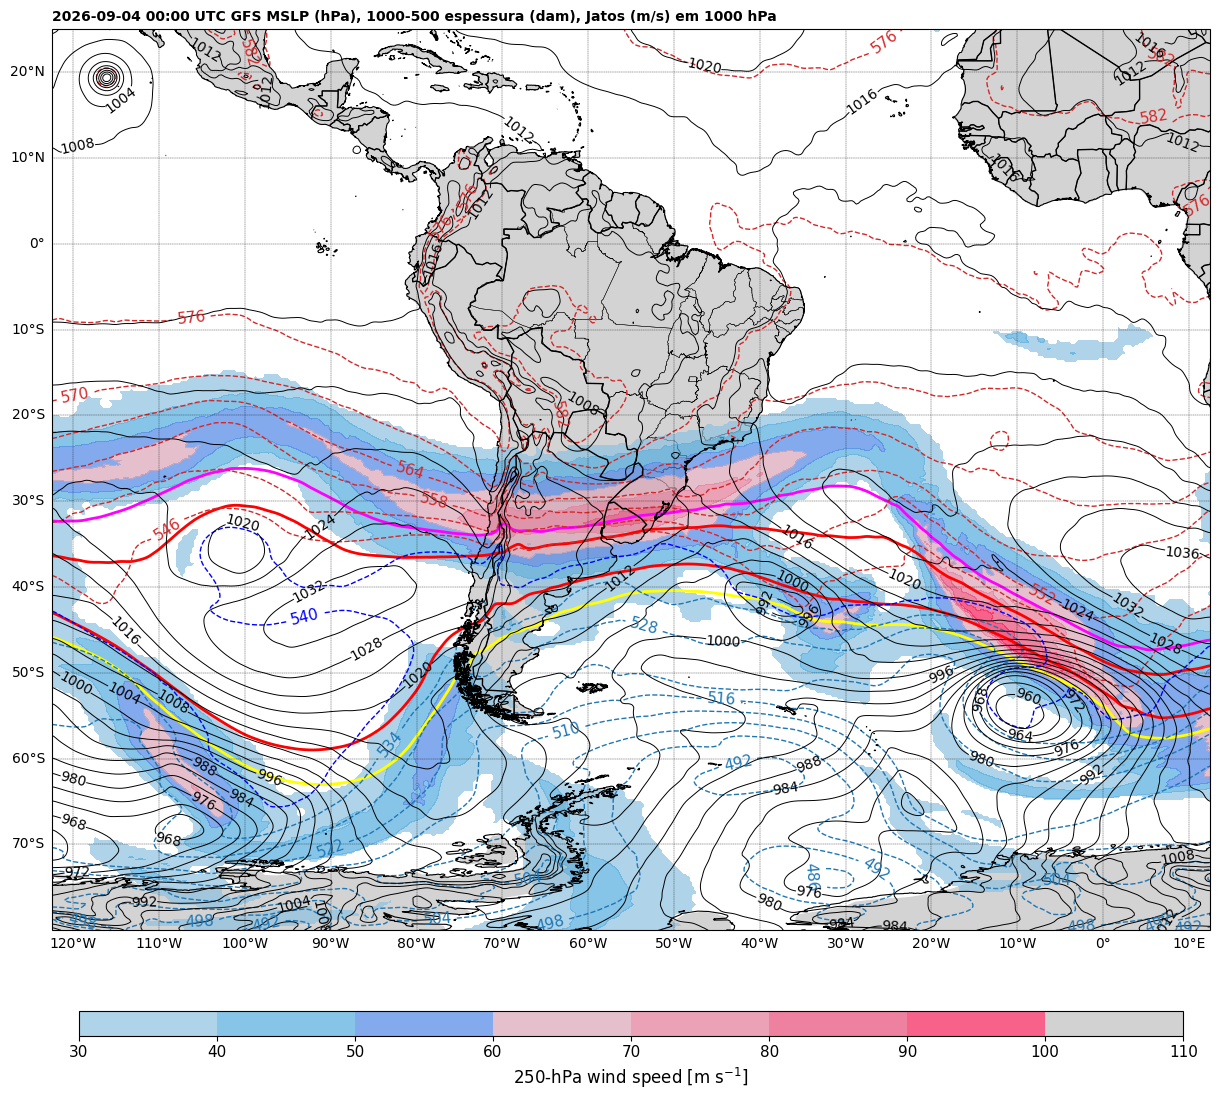

In [41]:
# @title #### <font color='#002883'> PRNMM + Espessura 1000-500 hPa + Jet 250 hPa em m/s<font>
#%%capture

# Choose the plot size (width x height, in inches)
plt.figure(figsize=(15,15))

# Use the Geostationary projection in cartopy
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([extent[0], extent[2], extent[1], extent[3]], ccrs.PlateCarree())

# =============================================================================================================================================
# IDENTIFICANDO OS JATOS
# =============================================================================================================================================

# ----------------------------------------------------------
# 250-hPa wind speed sombreado
# ----------------------------------------------------------
# Intervalos da barra
wind_levels = np.arange(30, 111, 10)   # 30, 40, ..., 110
# Cores aproximadas da sua paleta
wind_colors = [
    "#8ec1df",  # 30-40
    "#55addf",  # 40-50
    "#4d86e6",  # 50-60
    "#dba6b7",  # 60-70
    "#e47b98",  # 70-80
    "#e84c78",  # 80-90
    "#f61f58",  # 90-100
    "#bfbfbf",  # 100-110
]

# Colormap discreto
cmap_wind = mcolors.ListedColormap(wind_colors)
# Normalização por intervalos
norm_wind = mcolors.BoundaryNorm(wind_levels, cmap_wind.N)

# Suavizando o jato
speed_jet_plot = mpcalc.smooth_gaussian(speed_jet, 2)

jet250 = ax.contourf(
    lons,
    lats,
    speed_jet_plot,
    levels=wind_levels,
    cmap=cmap_wind,
    zorder=2,
    alpha=0.7,
    transform=ccrs.PlateCarree()
)

# Colorbar
cbar = plt.colorbar(
    jet250,
    ax=ax,
    orientation="horizontal",
    pad=0.07,
    aspect=45,
    shrink=0.95
)
cbar.set_ticks(wind_levels)
cbar.set_label("250-hPa wind speed [m s$^{-1}$]", fontsize=12)
cbar.ax.tick_params(labelsize=11)


# Plot Z - Jato Subtropical
hght_250_plot = mpcalc.smooth_gaussian(hght_250, 8)
clevzjet_subtropical = np.arange(10560., 10561., 1)

cs = ax.contour(lons, lats, hght_250_plot, clevzjet_subtropical, colors='magenta', linewidths=2.0, linestyles='-',transform=ccrs.PlateCarree())

# Plot Z - Ramo norte do Jato Polar
clevzjet_polar_norte = np.arange(10200., 10500., 240)
cs = ax.contour(lons, lats, hght_250_plot, clevzjet_polar_norte, colors='red', linewidths=2.0,linestyles='-',transform=ccrs.PlateCarree())

# Plot Z - Ramo Sul do Jato Polar
clevzjet_polar_sul = np.arange(10080., 10081., 1)
cs = ax.contour(lons, lats, hght_250_plot, clevzjet_polar_sul, colors='yellow', linewidths=2.0,linestyles='-',transform=ccrs.PlateCarree())

# =============================================================================================================================================
# MSLP E ESPESSURA 1000-500 hPa
# =============================================================================================================================================

# ESPSSURA 1000-500 hPa
# suavizado da espessura
thickness_1000_500_plot = mpcalc.smooth_gaussian(thickness_1000_500, 8)
# Plot thickness with multiple colors
clevs = (np.arange(0, 540, 6),
         np.array([540]),
         np.arange(546, 700, 6))
colors = ('tab:blue', 'b', 'tab:red')
kw_clabels = {'fontsize': 11, 'inline': True, 'inline_spacing': 5, 'fmt': '%i',
              'rightside_up': True, 'use_clabeltext': True}
for clevthick, color in zip(clevs, colors):
    img2 = ax.contour(
        lons,
        lats,
        thickness_1000_500_plot/10,
        levels=clevthick,
        colors=color,
        linewidths=1.0,
        linestyles='dashed',
        transform=ccrs.PlateCarree()
    )
    plt.clabel(img2, **kw_clabels)

# Suavizando a curva de mslp
mslp_plot = mpcalc.smooth_gaussian(mslp, 8)
# Define de contour interval
data_min = 900
data_max = 1050
interval = 4
levels = np.arange(data_min,data_max,interval)

# Plot the contours
img3 = ax.contour(
    lons,
    lats,
    mslp_plot,
    colors='black',
    linewidths=0.7,
    levels=levels
)
# Etiquetas
ax.clabel(
    img3,
    inline=1,
    inline_spacing=0,
    fontsize='10',
    fmt = '%1.0f',
    colors= 'black'
)

# ======================================================================

# Add a shapefile
# https://geoftp.ibge.gov.br/organizacao_do_territorio/malhas_territoriais/malhas_municipais/municipio_2019/Brasil/BR/br_unidades_da_federacao.zip
shapefile = list(shpreader.Reader('BR_UF_2019.shp').geometries())
ax.add_geometries(shapefile, ccrs.PlateCarree(), edgecolor='black',facecolor='none', linewidth=0.3)

# Add coastlines, borders and gridlines
ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=1)
ax.coastlines(resolution='10m', color='black', linewidth=0.8, zorder=3)
ax.add_feature(cfeature.BORDERS, edgecolor='black', linewidth=1, zorder=3)
ax.add_feature(cartopy.feature.BORDERS, edgecolor='black', linewidth=0.5)
gl = ax.gridlines(
    crs=ccrs.PlateCarree(),
    color='black',
    alpha=1.0,
    linestyle='--',
    linewidth=0.25,
    xlocs=np.arange(-180, 180, 10),
    ylocs=np.arange(-90, 90, 10),
    zorder=4,
    draw_labels=True
)
gl.top_labels = False
gl.right_labels = False

# Extract date
date = (datetime.strptime(dtime, '%Y-%m-%dT%H:%M:%S.%fZ'))

# Add a title
plt.title(date.strftime('%Y-%m-%d %H:%M') + ' UTC' + ' GFS MSLP (hPa), 1000-500 espessura (dam), Jatos (m/s) em 1000 hPa',
          fontweight='bold',
          fontsize=10, loc='left'
)
#plt.title('Reg.: ' + str(extent) , fontsize=10, loc='right')
#-----------------------------------------------------------------------------------------------------------
# Save the image
plt.savefig(f'{output}/MSLP_Thick_Jatos.png', bbox_inches='tight', pad_inches=0, dpi=300)

# Show the image
plt.show()

<font size=4 color='#002883'> **11. Plot da Altura geopotencial + Temperatura (°C, vermelho) + Vorticidade + omega negativo (movimento ascendente) e vento (knot, barbelas) em 500 hPa** <font>

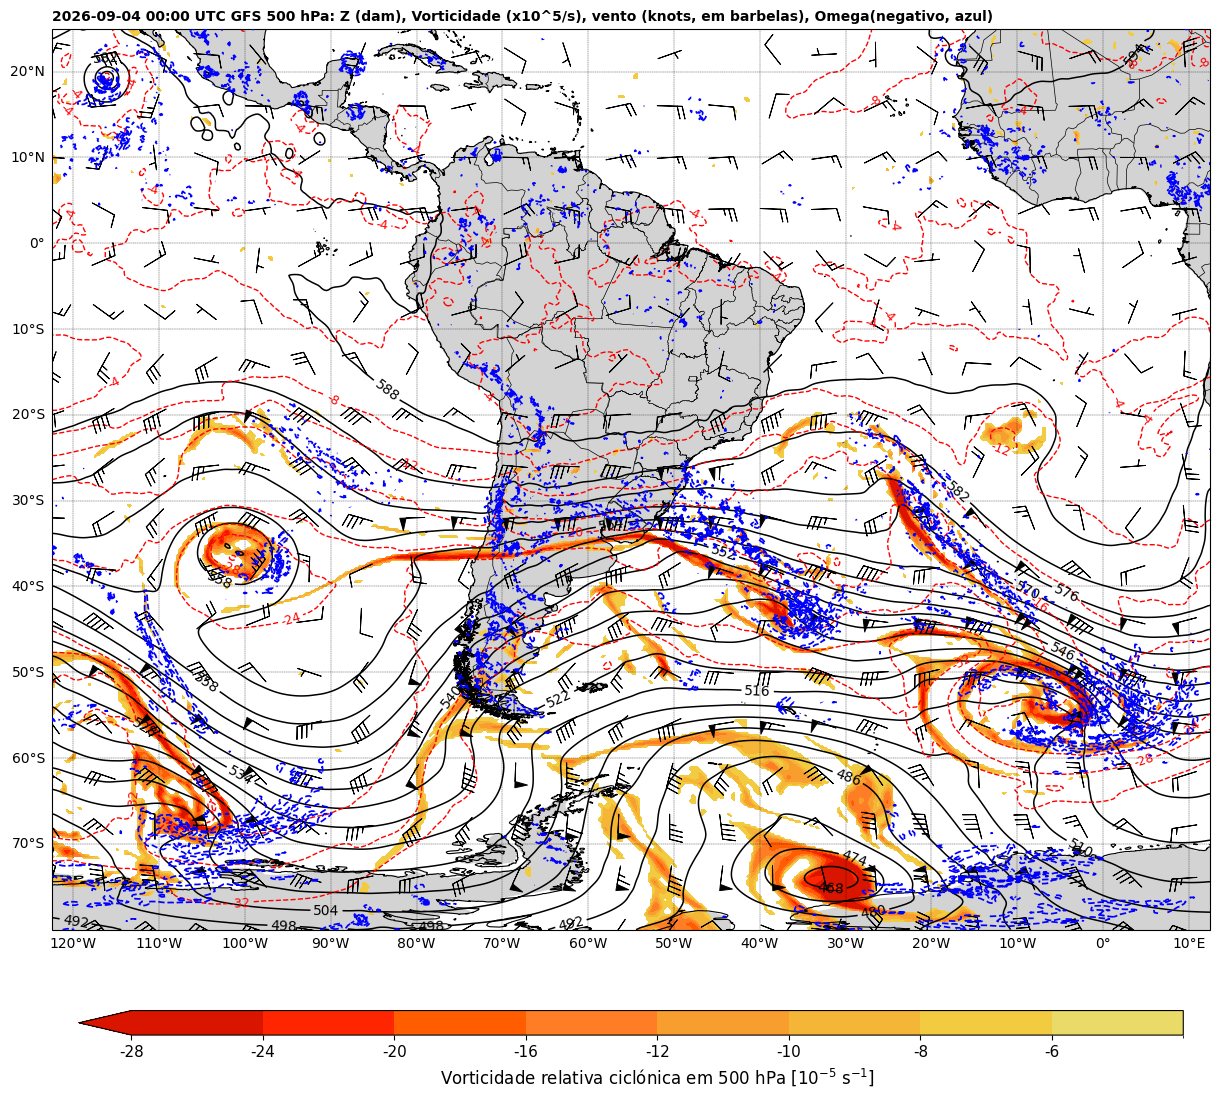

In [50]:

# @title #### <font color='#002883'> Altura geopotencial + Temperatura + Vorticidade ciclônica + Omega negativo + Vento. Level = 500 hPa<font>
#%%capture

# ====================================================================================================
# CRIAÇÃO DA FIGURA
# ====================================================================================================

# Choose the plot size (width x height, in inches)
plt.figure(figsize=(15,15))

# Use the Geostationary projection in cartopy
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([extent[0], extent[2], extent[1], extent[3]], ccrs.PlateCarree())

# -----------------------------------------------------------------------------
# VORTICIDADE RELATIVA EM 500 hPa
# -----------------------------------------------------------------------------
# 500-hPa vort
# Suavizado da vorticidade
zeta_500_plot = mpcalc.smooth_gaussian(zeta_500, 4)
# Vorticidade ciclônica no HS:
# No hemisfério sul, ciclônica = negativa
vort_cyc = xr.where(zeta_500_plot.magnitude <= -6e-5, zeta_500_plot.magnitude, np.nan)
# vorticidade relativa ciclônica (s^-1)
# ticks vão aparecer como x10^-5 s^-1
vort_levels = np.array([-28, -24, -20, -16, -12, -10, -8, -6, -4]) * 1e-5

# colormap aproximado da figura
vort_cmap = mcolors.ListedColormap([
    "#d91500",
    "#ff2500",
    "#ff5d00",
    "#ff7e25",
    "#f89e2e",
    "#f5b537",
    "#f2cb40",
    "#eadb68",
])
# Normalizar a barra de cores
vort_norm = mcolors.BoundaryNorm(vort_levels, vort_cmap.N)

# Plot da vorticidade
cf_vort = ax.contourf(
    lons,
    lats,
    vort_cyc,
    levels=vort_levels,
    cmap=vort_cmap,
    norm=vort_norm,
    extend="min",
    transform=ccrs.PlateCarree(),
    zorder=1
)
# Colorbar
cbar = plt.colorbar(
    cf_vort,
    ax=ax,
    orientation="horizontal",
    pad=0.07,
    aspect=45,
    shrink=0.95
)

# Etiquetas da colorbar
cbar.set_ticks(np.array([-28, -24, -20, -16, -12, -10, -8, -6]) * 1e-5)
cbar.set_ticklabels(["-28", "-24", "-20", "-16", "-12", "-10", "-8", "-6"])
cbar.ax.tick_params(labelsize=11)
cbar.set_label("Vorticidade relativa ciclónica em 500 hPa [$10^{-5}$ s$^{-1}$]", fontsize=12)

# ----------------------------------------------------------
# Altura geopotencial em preto
# ----------------------------------------------------------
# Plot Geopotential Heights
clevs_hght_500 = np.arange(0, 800, 6)
hght_500_plot = mpcalc.smooth_gaussian(hght_500, 8)
# Plot da altura geopotencial
cs = ax.contour(
    lons,
    lats,
    hght_500_plot/10,
    clevs_hght_500,
    colors='black',
    linewidths=1.1,
    transform=ccrs.PlateCarree(),
    zorder=2
)
# Etiquetas da altura geopotencial
ax.clabel(
    cs,
    fmt='%d',
    fontsize=10,
    inline=True,
    inline_spacing=3
)

# ----------------------------------------------------------
# Movimento ascendente em azul
# ----------------------------------------------------------
# Omega em hPa/s
# se w estiver em Pa/s, divide por 100
w500_hPas = w_500/100
# Suavizando a variável
w500_hPas_plot = w500_hPas  #mpcalc.smooth_gaussian(w500_hPas, 2)
# Ascensão (hPa/s)
omega_levels = [-0.030, -0.025, -0.020, -0.015, -0.010, -0.005]
# Plot do omega
ax.contour(
    lons, lats, w500_hPas_plot,
    levels=[-0.030, -0.025, -0.020, -0.015, -0.010, -0.005],
    colors="blue",
    linewidths=1.25,
    transform=ccrs.PlateCarree(),
    zorder=5
)

# ----------------------------------------------------------
# Temperatura em 500 hPa em vermelho
# ----------------------------------------------------------
# Suavizando a variável
temp_500_plot = mpcalc.smooth_gaussian(temp_500, 8)
# Temperatura (°C)
tempC_500_plot = temp_500_plot.to(units.celsius)
temp_levels = np.arange(-32, 5, 4)
# Plot da temperatura
cs_temp = ax.contour(
    lons,
    lats,
    tempC_500_plot.magnitude,
    levels=temp_levels,
    colors="red",
    linewidths=1.0,
    linestyles="dashed",
    transform=ccrs.PlateCarree(),
    zorder=2
)

ax.clabel(
    cs_temp,
    fmt="%d",
    fontsize=9,
    colors="red",
    inline=True,
    inline_spacing=3
)

# --------------------------------------------------------------------------
# VENTO EM KNOTS PARA O FORMATO DE BARBAS
# --------------------------------------------------------------------------
# Create a flag to determine which barbs are flipped
u_500_barb = u_500.to(units.knot)
v_500_barb = v_500.to(units.knot)
# Create a flag to determine which barbs are flipped
flip_flag = np.zeros((u_500_barb.shape[0],u_500_barb.shape[1]))

# All flags below the equator will be flipped
flip_flag[lats < 0] = 1

# Espaçamento das baerbelas
skip=24
bcolor='black'
# Suavizando os ventos
u_500_barb_plot = mpcalc.smooth_gaussian(u_500_barb, 8)
v_500_barb_plot = mpcalc.smooth_gaussian(v_500_barb, 8)
# plot da variável
img4 = ax.barbs(
    lons[::skip,::skip],
    lats[::skip,::skip],
    u_500_barb_plot[::skip,::skip], v_500_barb_plot[::skip,::skip],
    length = 6.0,
    sizes = dict(emptybarb=0.0, spacing=0.2, height=0.5),
    linewidth=0.7,
    pivot='middle',
    barbcolor=bcolor,
    flip_barb = flip_flag[::skip,::skip],
    zorder=3
)

# -----------------------------------------------------------------------------

# Add a shapefile
# https://geoftp.ibge.gov.br/organizacao_do_territorio/malhas_territoriais/malhas_municipais/municipio_2019/Brasil/BR/br_unidades_da_federacao.zip
shapefile = list(shpreader.Reader('BR_UF_2019.shp').geometries())
ax.add_geometries(shapefile, ccrs.PlateCarree(), edgecolor='black',facecolor='none', linewidth=0.3)

# Add coastlines, borders and gridlines
ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=0)
ax.coastlines(resolution='10m', color='black', linewidth=0.8, zorder=3)
ax.add_feature(cartopy.feature.BORDERS, edgecolor='black', linewidth=0.5, zorder=3)
gl = ax.gridlines(
    crs=ccrs.PlateCarree(),
    color='black',
    alpha=1.0,
    linestyle='--',
    linewidth=0.25,
    xlocs=np.arange(-180, 180, 10),
    ylocs=np.arange(-90, 90, 10),
    draw_labels=True
)
gl.top_labels = False
gl.right_labels = False

# Extract date
date = (datetime.strptime(dtime, '%Y-%m-%dT%H:%M:%S.%fZ'))

# Add a title
plt.title(date.strftime('%Y-%m-%d %H:%M') + ' UTC' + ' GFS 500 hPa: Z (dam), Vorticidade (x10^5/s), vento (knots, em barbelas), Omega(negativo, azul)',
          fontweight='bold',
          fontsize=10,
          loc='left'
)

#-----------------------------------------------------------------------------------------------------------
# Save the image
plt.savefig(f'{output}/500_Vort.png', bbox_inches='tight', pad_inches=0, dpi=300)

# Show the image
plt.show()

<font size=4 color='#002883'> **12. Plot da Altura geopotencial + Temperatura (°C, vermelho) + Água Precipitável (mm) e vento (knot, barbelas) em 700 hPa** <font>

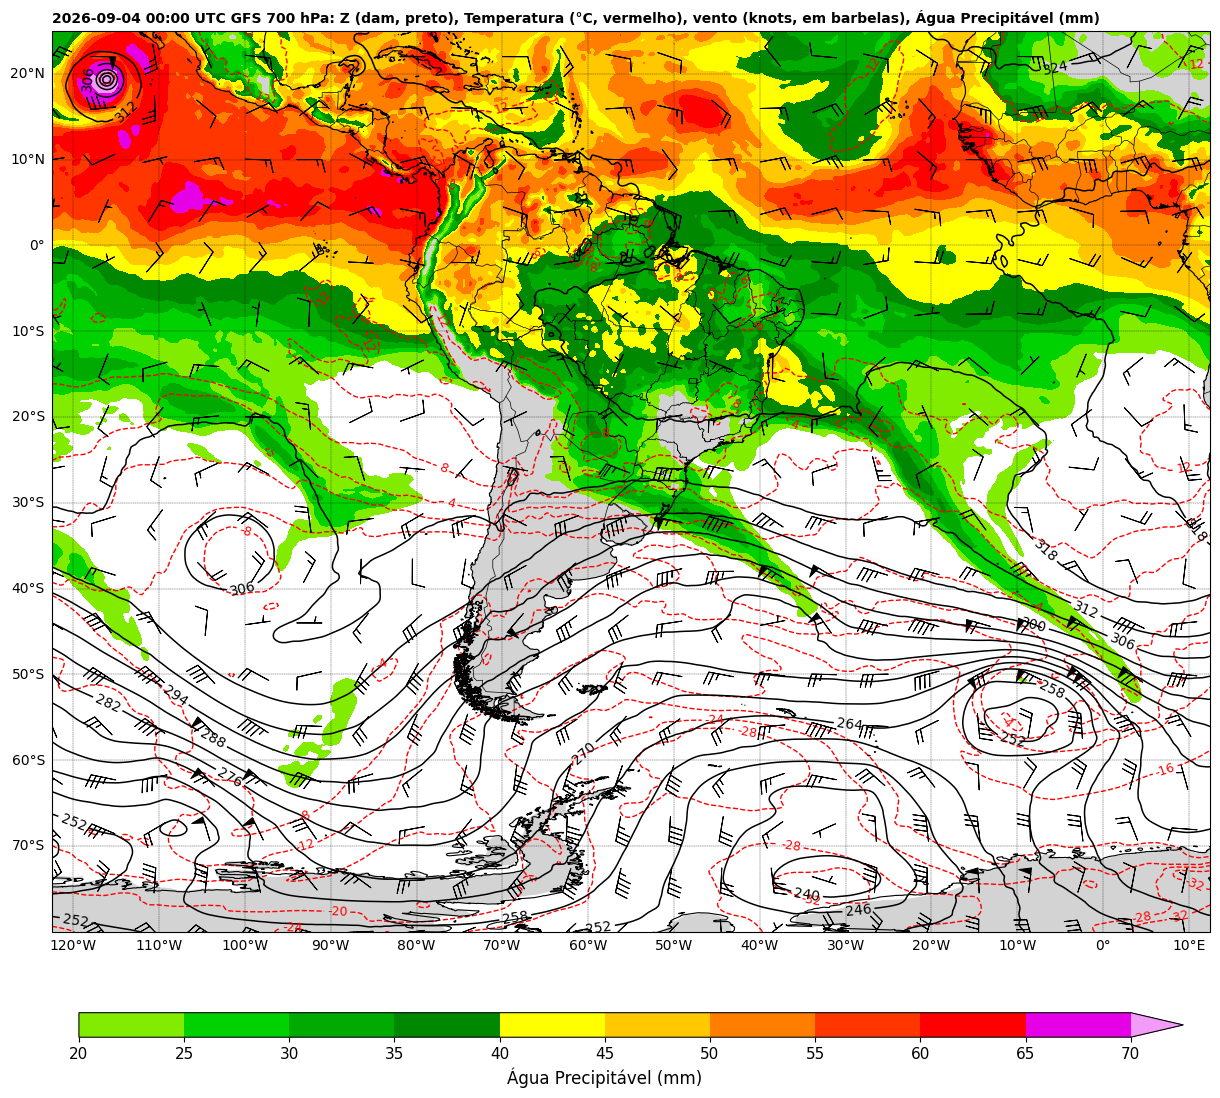

In [51]:
# @title #### <font color='#002883'> Altura geopotencial + Temperatura + Vento (barbelas) + Água precipitável. Level = 700 hPa<font>
#%%capture

# ====================================================================================================
# CRIAÇÃO DA FIGURA
# ====================================================================================================

# Choose the plot size (width x height, in inches)
plt.figure(figsize=(15,15))

# Use the Geostationary projection in cartopy
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([extent[0], extent[2], extent[1], extent[3]], ccrs.PlateCarree())

# -----------------------------------------------------------------------------
# ÁGUA PRECIPITÁVEL
# -----------------------------------------------------------------------------
# Suavizado da água precipitável
prtwt_plot = mpcalc.smooth_gaussian(prtwt, 4)

# Níveis em mm conforme a imagem (20 a 70 mm, de 5 em 5)
prtwt_levels = np.array([20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70])

# Paleta de cores replicada exatamente da imagem (11 cores para 10 intervalos)
prtwt_cmap = mcolors.ListedColormap([
    #"#ffffff",  # < 20 (Branco)
    "#82ec00",  # 20 - 25 (Verde claro / Lima)
    "#00d100",  # 25 - 30 (Verde)
    "#00aa00",  # 30 - 35 (Verde médio)
    "#008800",  # 35 - 40 (Verde escuro)
    "#ffff00",  # 40 - 45 (Amarelo)
    "#ffc800",  # 45 - 50 (Laranja claro)
    "#ff7e00",  # 50 - 55 (Laranja)
    "#ff3600",  # 55 - 60 (Laranja avermelhado)
    "#ff0000",  # 60 - 65 (Vermelho)
    "#e600e6",  # 65 - 70 (Magenta)
])

# Para o tom rosado no final (> 70)
prtwt_cmap.set_over("#f39bf8")

# Normalizar a barra de cores
prtwt_norm = mcolors.BoundaryNorm(prtwt_levels, prtwt_cmap.N)

# Plot da água precipitável (corrigido: levels=prtwt_levels)
cf_prtwt = ax.contourf(
    lons,
    lats,
    prtwt_plot,
    levels=prtwt_levels,
    cmap=prtwt_cmap,
    norm=prtwt_norm,
    extend="max",
    transform=ccrs.PlateCarree(),
    zorder=1
)

# Colorbar
cbar = plt.colorbar(
    cf_prtwt,
    ax=ax,
    orientation="horizontal",
    pad=0.07,
    aspect=45,
    shrink=0.95
)

# Etiquetas da colorbar
cbar.set_ticks(prtwt_levels)
cbar.set_ticklabels(["20", "25", "30", "35", "40", "45", "50", "55", "60", "65", "70"])
cbar.ax.tick_params(labelsize=11)
cbar.set_label("Água Precipitável (mm)", fontsize=12)

# ----------------------------------------------------------
# Altura geopotencial em preto
# ----------------------------------------------------------
# Plot Geopotential Heights
clevs_hght_700 = np.arange(0, 331, 6)
hght_700_plot = mpcalc.smooth_gaussian(hght_700, 4)
# Plot da altura geopotencial
cs = ax.contour(
    lons,
    lats,
    hght_700_plot/10,
    clevs_hght_700,
    colors='black',
    linewidths=1.1,
    transform=ccrs.PlateCarree(),
    zorder=3
)
# Etiquetas da altura geopotencial
ax.clabel(
    cs,
    fmt='%d',
    fontsize=10,
    inline=True,
    inline_spacing=3
)

# ----------------------------------------------------------
# Temperatura em 700 hPa em vermelho
# ----------------------------------------------------------
# Suavizando a variável
temp_700_plot = mpcalc.smooth_gaussian(temp_700, 8)
# Temperatura (°C)
tempC_700_plot = temp_700_plot.to(units.celsius)
temp_levels = np.arange(-32, 16, 4)
# Plot da temperatura
cs_temp = ax.contour(
    lons,
    lats,
    tempC_700_plot.magnitude,
    levels=temp_levels,
    colors="red",
    linewidths=1.0,
    linestyles="dashed",
    transform=ccrs.PlateCarree(),
    zorder=2
)

ax.clabel(
    cs_temp,
    fmt="%d",
    fontsize=9,
    colors="red",
    inline=True,
    inline_spacing=3
)

# --------------------------------------------------------------------------
# VENTO EM KNOTS PARA O FORMATO DE BARBAS
# --------------------------------------------------------------------------
# Create a flag to determine which barbs are flipped
u_700_barb = units('m/s') * u_700.to(units.knot)
v_700_barb = units('m/s') * v_700.to(units.knot)
# Create a flag to determine which barbs are flipped
flip_flag = np.zeros((u_700_barb.shape[0],u_700_barb.shape[1]))

# All flags below the equator will be flipped
flip_flag[lats < 0] = 1

# Espaçamento das baerbelas
skip=24
bcolor='black'
# Suavizando os ventos
u_700_barb_plot = mpcalc.smooth_gaussian(u_700_barb, 8)
v_700_barb_plot = mpcalc.smooth_gaussian(v_700_barb, 8)
# plot da variável
img4 = ax.barbs(
    lons[::skip,::skip],
    lats[::skip,::skip],
    u_700_barb_plot[::skip,::skip],
    v_700_barb_plot[::skip,::skip],
    length = 6.0,
    sizes = dict(emptybarb=0.0, spacing=0.2, height=0.5),
    linewidth=0.7,
    pivot='middle',
    barbcolor=bcolor,
    flip_barb = flip_flag[::skip,::skip],
    zorder=3
)

# -----------------------------------------------------------------------------

# Add a shapefile
# https://geoftp.ibge.gov.br/organizacao_do_territorio/malhas_territoriais/malhas_municipais/municipio_2019/Brasil/BR/br_unidades_da_federacao.zip
shapefile = list(shpreader.Reader('BR_UF_2019.shp').geometries())
ax.add_geometries(shapefile, ccrs.PlateCarree(), edgecolor='black',facecolor='none', linewidth=0.3)

# Add coastlines, borders and gridlines
ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=0)
ax.coastlines(resolution='10m', color='black', linewidth=0.8, zorder=3)
ax.add_feature(cartopy.feature.BORDERS, edgecolor='black', linewidth=0.5, zorder=3)
gl = ax.gridlines(
    crs=ccrs.PlateCarree(),
    color='black',
    alpha=1.0,
    linestyle='--',
    linewidth=0.25,
    xlocs=np.arange(-180, 180, 10),
    ylocs=np.arange(-90, 90, 10),
    draw_labels=True
)
gl.top_labels = False
gl.right_labels = False

# Extract date
date = (datetime.strptime(dtime, '%Y-%m-%dT%H:%M:%S.%fZ'))

# Add a title
plt.title(date.strftime('%Y-%m-%d %H:%M') + ' UTC' + ' GFS 700 hPa: Z (dam, preto), Temperatura (°C, vermelho), vento (knots, em barbelas), Água Precipitável (mm)',
          fontweight='bold',
          fontsize=10,
          loc='left'
)

#-----------------------------------------------------------------------------------------------------------
# Save the image
plt.savefig(f'{output}/700_Precipwater_Z_Temp_Wind.png', bbox_inches='tight', pad_inches=0, dpi=300)

# Show the image
plt.show()

<font size=4 color='#002883'> **13. Plot da MSLP + Temperatura (°C, vermelho/azul) + Precipitação (mm/6h) e vento (knot, barbelas) em 1000 hPa** <font>

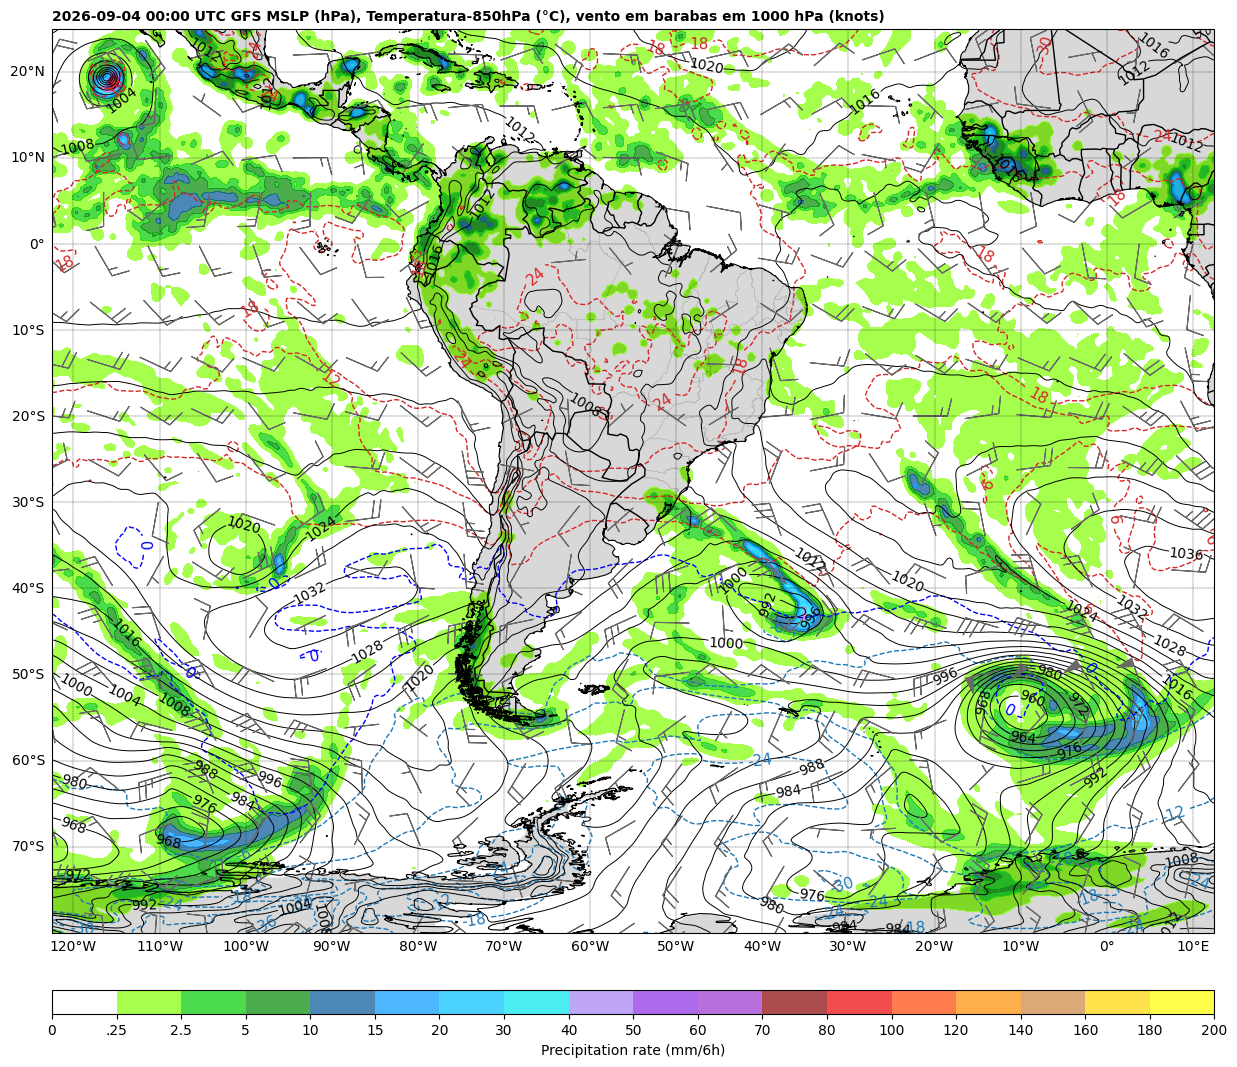

In [55]:
# @title #### <font color='#002883'> MSLP + Precipitation rate [mm/6h] + Temperatura 850 + Vento 1000 hPa <font>
#%%capture

# =======================================================================================================
# CRIANDO A BARRA DE CORES BASEADO NO SITE:
# Link: https://www.atmos.albany.edu/student/abentley/realtime.html
# =======================================================================================================
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib as mpl
import cartopy.feature as cfeature

# 1. Definição das Cores Exatas da sua Imagem (Lista de Hexadecimais)
# Começa no branco (0-0.25) e termina no creme claro (>200)
hex_colors = [
    '#FFFFFF',  # 0.0 - 0.25  (Branco)
    '#7FFF00',  # 0.25 - 2.5  (Verde Limão claro)
    '#00CD00',  # 2.5 - 5.0   (Verde Vibrante)
    '#008B00',  # 5.0 - 10.0  (Verde Escuro)
    '#005596',  # 10.0 - 15.0 (Azul Marinho)
    '#0099FF',  # 15.0 - 20.0 (Azul Piscina)
    '#00BFFF',  # 20.0 - 30.0 (Ciano)
    '#00E5EE',  # 30.0 - 40.0 (Ciano Claro)
    '#A47FF3',  # 40.0 - 50.0 (Lilás)
    '#8A2BE2',  # 50.0 - 60.0 (Violeta Profundo)
    '#9932CC',  # 60.0 - 70.0 (Roxo "Dark Orchid")
    '#8B0000',  # 70.0 - 80.0 (Vermelho Escuro/Vinho)
    '#EE0000',  # 80.0 - 100.0(Vermelho Puro)
    '#FF4500',  # 100 - 120   (Laranja Avermelhado)
    '#FF8C00',  # 120 - 140   (Laranja "Dark Orange")
    '#CD853F',  # 140 - 160   (Laranja Queimado/"Peru")
    '#FFD700',  # 160 - 180   (Ouro/Amarelo Escuro)
    '#FFFF00',  # 180 - 200   (Amarelo Puro)
    '#FFFACD'   # > 200        (Creme/"Lemon Chiffon")
]

# 2. Definição dos Limites (Níveis)
# Baseado na sua lista 'clevpreciprate'
bounds = [0, 0.25, 2.5, 5, 10, 15, 20, 30, 40, 50, 60, 70, 80, 100, 120, 140, 160, 180, 200, 250]
# Nota: Adicionei '250' apenas para definir o último intervalo colorido.

# 3. Criando o Objeto Colormap e Normalização
# Cria um colormap "listado" (discreto) com as cores definidas
custom_cmap = mcolors.ListedColormap(hex_colors)
# Cria uma normalização "por fronteiras", essencial para dados meteorológicos/discretos
norm = mcolors.BoundaryNorm(bounds, custom_cmap.N)

# Choose the plot size (width x height, in inches)
plt.figure(figsize=(15,15))

# Use the Geostationary projection in cartopy
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([extent[0], extent[2], extent[1], extent[3]], ccrs.PlateCarree())

# Plotando Precipitation rate
clevpreciprate = [0, 0.25, 2.5, 5, 10, 15, 20, 30, 40, 50, 60, 70, 80, 100, 120, 140, 160, 180, 200]
# Criando o vetor com os valores de precipitação
precip_rate_values = precip_rate.values  # <--- .values é indispensável aqui!
# Se o dado estiver em kg/m²/s e você quiser exibir em mm/6h:
precip_rate_mm6h = precip_rate_values * 3600 * 6
# Suavizando a variável
precip_rate_mm6h_plot = mpcalc.smooth_gaussian(precip_rate_mm6h, 8)
# Gerando o plot
cs2 = ax.contourf(
    lons,
    lats,
    precip_rate_mm6h_plot,
    clevpreciprate,
    cmap =custom_cmap,
    norm=norm,
    alpha=0.7,
    zorder=2
)

# Gerando a barra do Precipitation rate (mm/6h)
cb = plt.colorbar(
    cs2,
    label='Precipitation rate (mm/6h)',
    orientation="horizontal",
    ticks=clevpreciprate,
    pad=0.05,
    aspect=50
)

# Ajuste os rótulos (opcional, para replicar o estilo da imagem)
ticks = [str(x) if x != 0.25 else '.25' for x in clevpreciprate]
cb.ax.set_xticklabels(ticks)

# ==========================================================================
# TEMPERATURA EM 850 hPa
# ==========================================================================
# 850-hPa T
temp_850_C = temp_850.to(units.degC)
# Suavizando a variável
temp_850_C_plot = mpcalc.smooth_gaussian(temp_850_C, 8)
# Plot thickness with multiple colors
clevs = (np.arange(-36, 0, 6),
         np.array([0]),
         np.arange(6, 37, 6))
colors = ('tab:blue', 'b', 'tab:red')
kw_clabels = {'fontsize': 11, 'inline': True, 'inline_spacing': 5, 'fmt': '%i',
              'rightside_up': True, 'use_clabeltext': True}
for clevthick, color in zip(clevs, colors):
    img2 = ax.contour(
        lons,
        lats,
        temp_850_C_plot,
        levels=clevthick,
        colors=color,
        linewidths=1.0,
        linestyles='dashed',
        transform=ccrs.PlateCarree()
    )
    plt.clabel(img2, **kw_clabels)

# Define de contour interval
data_min = 900
data_max = 1050
interval = 4
levels = np.arange(data_min,data_max,interval)

# Plot the contours
img3 = ax.contour(
    lons,
    lats,
    mslp_plot,
    colors='black',
    linewidths=0.7,
    levels=levels
)
# Etiquetas
ax.clabel(
    img3,
    inline=1,
    inline_spacing=0,
    fontsize='10',
    fmt = '%1.0f',
    colors= 'black'
)

# ==========================================================================
# VENTO EM KNOTS PARA O FORMATO DE BARBAS
# ==========================================================================
# Create a flag to determine which barbs are flipped
u_1000_barb = u_1000.to(units.knot)
v_1000_barb = v_1000.to(units.knot)
flip_flag = np.zeros((u_1000_barb.shape[0],u_1000_barb.shape[1]))

# All flags below the equator will be flipped
flip_flag[lats < 0] = 1

# Plot the barbs
skip=24
bcolor='dimgrey'
# Suavizando os ventos
u_1000_barb_plot = mpcalc.smooth_gaussian(u_1000_barb, 8)
v_1000_barb_plot = mpcalc.smooth_gaussian(v_1000_barb, 8)
# Plot do vento em barbelas
img4 = ax.barbs(
    lons[::skip,::skip],
    lats[::skip,::skip],
    u_1000_barb_plot[::skip,::skip],
    v_1000_barb_plot[::skip,::skip],
    length = 7.0,
    sizes = dict(emptybarb=0.0, spacing=0.2, height=0.5),
    linewidth=0.8,
    pivot='middle',
    barbcolor=bcolor,
    flip_barb = flip_flag[::skip,::skip],
    zorder=2
)

# ======================================================================

# Add a shapefile
# https://geoftp.ibge.gov.br/organizacao_do_territorio/malhas_territoriais/malhas_municipais/municipio_2019/Brasil/BR/br_unidades_da_federacao.zip
shapefile = list(shpreader.Reader('BR_UF_2019.shp').geometries())
ax.add_geometries(shapefile, ccrs.PlateCarree(), edgecolor='black',facecolor='none', linewidth=0.3)

# Add coastlines, borders and gridlines
ax.add_feature(cfeature.LAND, facecolor='gray', zorder=1)
ax.coastlines(resolution='10m', color='black', linewidth=0.8, zorder=3)
ax.add_feature(cfeature.BORDERS, edgecolor='black', linewidth=1, zorder=3)
ax.add_feature(cartopy.feature.BORDERS, edgecolor='black', linewidth=0.5)
gl = ax.gridlines(
    crs=ccrs.PlateCarree(),
    color='black',
    alpha=1.0,
    linestyle='--',
    linewidth=0.25,
    xlocs=np.arange(-180, 180, 10),
    ylocs=np.arange(-90, 90, 10),
    zorder=4,
    draw_labels=True
)
gl.top_labels = False
gl.right_labels = False

# Extract date
date = (datetime.strptime(dtime, '%Y-%m-%dT%H:%M:%S.%fZ'))

# Add a title
plt.title(date.strftime('%Y-%m-%d %H:%M') + ' UTC' + ' GFS MSLP (hPa), Temperatura-850hPa (°C), vento em barabas em 1000 hPa (knots)',
          fontweight='bold',
          fontsize=10, loc='left'
)
#plt.title('Reg.: ' + str(extent) , fontsize=10, loc='right')
#-----------------------------------------------------------------------------------------------------------
# Save the image
plt.savefig(f'{output}/MSLP_Thick_Jatos.png', bbox_inches='tight', pad_inches=0, dpi=300)

# Show the image
plt.show()

<font size=4 color='#002883'> **14. Criação de Função para o cálculo do Integrated Water Vapor Transport (IVT)** <font>

In [77]:
# @title #### <font color='#002883'> Função para calcular o Integrated Water Vapor Transport (IVT) <font>
#%%capture

def calculate_ivt(ds, q_var="q", u_var="u", v_var="v", p_dim="level"):
    """Calculates the magnitude and components of Integrated Water Vapor Transport (IVT).

    Parameters:
    -----------
    ds : xarray.Dataset
        Dataset containing specific humidity, zonal, and meridional winds.
    q_var : str
        Name of the specific humidity variable (expected in kg/kg).
    u_var : str
        Name of the zonal wind variable (m/s).
    v_var : str
        Name of the meridional wind variable (m/s).
    p_dim : str
        Name of the pressure vertical coordinate dimension.

    Returns:
    --------
    ivt_ds : xarray.Dataset
        Dataset containing 'QU' (kg m-1 s-1), 'QV' (kg m-1 s-1), and 'IVT'
        magnitude.
    """
    # 1. Define constants
    g = 9.80665  # Acceleration due to gravity (m/s^2)

    # 2. Extract variables and sort pressure from surface to top (e.g., 1000
    # hPa down to 300 hPa)
    # This ensures a correct directional integration axis
    ds = ds.sortby(p_dim, ascending=False)

    q = ds[q_var]  # kg/kg
    u = ds[u_var]  # m/s
    v = ds[v_var]  # m/s

    # 3. Convert pressure levels to Pascals (Pa) for SI unit consistency
    # If your data is already in Pa, remove the multiplier
    if ds[p_dim].attrs.get("units", "hPa") == "hPa" or ds[p_dim].max() < 2000:
        pressure_pa = ds[p_dim] * 100.0
    else:
        pressure_pa = ds[p_dim]

    # 4. Compute horizontal vapor transport at each pressure level
    qu_levels = q * u
    qv_levels = q * v

    # Find the axis index of the pressure dimension for integration
    axis_idx = q.get_axis_num(p_dim)

    # 5. Integrate vertically using the trapezoidal rule
    # Formula: -1/g * integral(q * u dp)
    # We drop the negative sign if integrating from highest pressure (surface) to lowest (top)
    qu_int = -np.trapz(qu_levels, x=pressure_pa, axis=axis_idx) / g
    qv_int = -np.trapz(qv_levels, x=pressure_pa, axis=axis_idx) / g

    # 6. Calculate total IVT magnitude
    ivt_magnitude = np.sqrt(qu_int**2 + qv_int**2)

    # 7. Package results back into an xarray Dataset with matching coordinates
    # We drop the vertical dimension since it has been integrated out
    coords = {dim: ds[dim] for dim in ds.dims if dim != p_dim}

    ivt_ds = xr.Dataset(
        data_vars={
            "QU": (tuple(coords.keys()), qu_int),
            "QV": (tuple(coords.keys()), qv_int),
            "IVT": (tuple(coords.keys()), ivt_magnitude),
        },
        coords=coords,
    )

    # Add attributes/units
    ivt_ds["QU"].attrs = {"units": "kg m-1 s-1", "long_name": "Zonal IVT"}
    ivt_ds["QV"].attrs = {
        "units": "kg m-1 s-1",
        "long_name": "Meridional IVT",
    }
    ivt_ds["IVT"].attrs = {
        "units": "kg m-1 s-1",
        "long_name": "Integrated Water Vapor Transport Magnitude",
    }

    return ivt_ds


<font size=4 color='#002883'> **15. Aplicação da Função que calcula o Integrated Water Vapor Transport (IVT). Nesta parte é utilizada o dataset que foi transformado do grib para NetCDF.** <font>

In [78]:
# @title #### <font color='#002883'> Aplicação do Função calculate_ivt <font>
#%%capture
ivt_ds = calculate_ivt(ds, q_var='q', u_var='u', v_var='v', p_dim='isobaricInhPa')
ivt_ds

<xarray.Dataset> Size: 5MB
Dimensions:     (latitude: 421, longitude: 541)
Coordinates:
  * latitude    (latitude) float64 3kB -80.0 -79.75 -79.5 ... 24.5 24.75 25.0
  * longitude   (longitude) float64 4kB -122.5 -122.2 -122.0 ... 12.0 12.25 12.5
    time        datetime64[ns] 8B 2026-09-04
    step        timedelta64[ns] 8B 00:00:00
    valid_time  datetime64[ns] 8B 2026-09-04
Data variables:
    QU          (latitude, longitude) float64 2MB 19.18 18.96 ... -72.59 -70.02
    QV          (latitude, longitude) float64 2MB -27.89 -28.04 ... -173.5
    IVT         (latitude, longitude) float64 2MB 33.85 33.85 ... 189.1 187.1

<font size=4 color='#002883'> **16. Plot: Altura Geopotencial (dam) em 700 hPa, Integrated Water Vapor Transport (IVT)** <font>

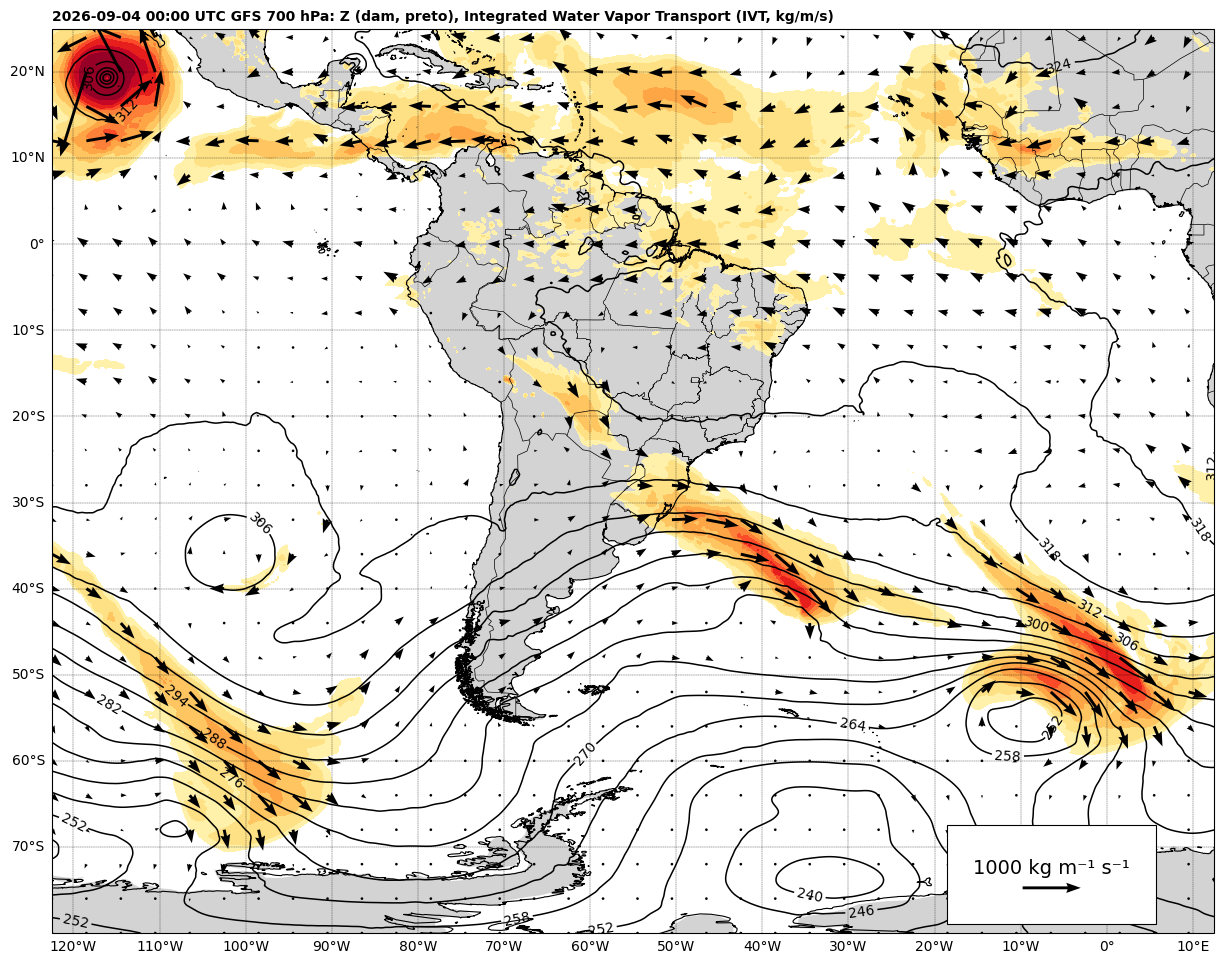

In [92]:
# @title #### <font color='#002883'> Altura geopotencial + Temperatura + Vento (barbelas) + Água precipitável. Level = 700 hPa<font>
#%%capture

# ====================================================================================================
# CRIAÇÃO DA FIGURA
# ====================================================================================================

# --- LEGENDA DO VETOR NO CANTO INFERIOR DIREITO ---
import matplotlib.patches as patches

# Choose the plot size (width x height, in inches)
plt.figure(figsize=(15,15))

# Use the Geostationary projection in cartopy
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([extent[0], extent[2], extent[1], extent[3]], ccrs.PlateCarree())

# -----------------------------------------------------------------------------
# INTEGRATED WATER VAPOR TRANSPORT - IVT
# -----------------------------------------------------------------------------

# Definir os níveis exatos (10 limites geram exatamente 9 intervalos)
ivt_levels = [250, 300, 400, 500, 600, 700, 800, 1000, 1200, 1400]

# Capturar uma paleta contínua e extrair 9 cores perfeitamente distribuídas
# 'YlOrRd' garante a transição do Amarelo -> Laranja -> Vermelho de forma linear
cmap_base = mpl.colormaps["YlOrRd"]
ivt_colors = cmap_base(np.linspace(0.1, 0.95, len(ivt_levels) - 1))

# Criar um mapa de cores customizado e o normalizador por fronteiras (Norm)
# Isso força o Matplotlib a tratar cada intervalo de forma discreta e única
custom_cmap = mpl.colors.ListedColormap(ivt_colors)
norm = mpl.colors.BoundaryNorm(ivt_levels, custom_cmap.N)

# PLOTAR O MAPA COM CONTOURF
cf = ax.contourf(
    ivt_ds['longitude'],
    ivt_ds['latitude'],
    ivt_ds['IVT'],
    levels=ivt_levels,
    cmap=custom_cmap,
    norm=norm,
    extend="max",  # Seta no final para valores > 1400 (usará o vermelho mais escuro)
    transform=ccrs.PlateCarree(),
    zorder=2,
)

# PLOTAGEM DOS VETORES DE IVT (Setas)
# Para não poluir o mapa, pulamos alguns pontos de grade (skip/thinning)
skip = 16  # Ajuste esse número dependendo da resolução do seu dado
quiver_plot = ax.quiver(
    ivt_ds['longitude'][::skip],
    ivt_ds['latitude'][::skip],
    ivt_ds['QU'][::skip, ::skip],
    ivt_ds['QV'][::skip, ::skip],
    transform=ccrs.PlateCarree(),
    color="black",
    # --- PARÂMETROS DE CONTROLE ---
    scale=20000,  # [COMPRIMENTO] QUANTO MENOR este número, MAIORES serão as setas
    width=0.0025,  # [ESPESSURA] Diâmetro da haste da seta (fração da largura da figura)
    headwidth=3.5,  # [CABEÇA] Largura da ponta da seta em relação à espessura da haste
    headlength=5.0,  # [CABEÇA] Comprimento da ponta da seta
    zorder=5,
)

# CONFIGURAÇÃO DA SETA BEM PRÓXIMO AO EIXO INFERIOR ---
# Reduzimos o Y para 0.05 para colar a seta e o texto na borda inferior direita
quiver_legend = ax.quiverkey(
    quiver_plot,
    X=0.86,  # Posição horizontal da seta
    Y=0.05,  # Posição vertical (bem baixa, rente ao eixo)
    U=1000,
    label="1000 kg m⁻¹ s⁻¹",
    labelpos="N",  # Texto acima da seta
    coordinates="axes",
    fontproperties={"size": 14, "weight": "normal"},
    zorder=6,  # Garante que a seta e o texto fiquem NA FRENTE da caixa branca
)

# CAIXA BRANCA AJUSTADA PARA ENGLOBAR TUDO ---
# Desenhamos um retângulo usando as coordenadas do próprio eixo (0 a 1)
# O retângulo começa na base (y=0.01) e vai até o canto direito (x=0.75 até quase 1.0)
rect = patches.Rectangle(
    (0.77, 0.01),  # (x, y) do canto inferior esquerdo da caixinha
    0.18,  # Largura da caixinha
    0.11,  # Altura da caixinha (ajustada para cobrir o texto 'N')
    transform=ax.transAxes,
    facecolor="white",
    edgecolor="black",
    linewidth=0.8,
    zorder=5,  # Fica ATRÁS da seta/texto, mas ACIMA do mapa/linhas
)

# Adiciona a caixinha ao mapa
ax.add_patch(rect)

# ----------------------------------------------------------
# Altura geopotencial em preto
# ----------------------------------------------------------
# Plot Geopotential Heights
clevs_hght_700 = np.arange(0, 331, 6)
hght_700_plot = mpcalc.smooth_gaussian(hght_700, 4)
# Plot da altura geopotencial
cs = ax.contour(
    lons,
    lats,
    hght_700_plot/10,
    clevs_hght_700,
    colors='black',
    linewidths=1.1,
    transform=ccrs.PlateCarree(),
    zorder=3
)
# Etiquetas da altura geopotencial
ax.clabel(
    cs,
    fmt='%d',
    fontsize=10,
    inline=True,
    inline_spacing=3
)

# -----------------------------------------------------------------------------

# Add a shapefile
# https://geoftp.ibge.gov.br/organizacao_do_territorio/malhas_territoriais/malhas_municipais/municipio_2019/Brasil/BR/br_unidades_da_federacao.zip
shapefile = list(shpreader.Reader('BR_UF_2019.shp').geometries())
ax.add_geometries(shapefile, ccrs.PlateCarree(), edgecolor='black',facecolor='none', linewidth=0.3)

# Add coastlines, borders and gridlines
ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=0)
ax.coastlines(resolution='10m', color='black', linewidth=0.8, zorder=3)
ax.add_feature(cartopy.feature.BORDERS, edgecolor='black', linewidth=0.5, zorder=3)
gl = ax.gridlines(
    crs=ccrs.PlateCarree(),
    color='black',
    alpha=1.0,
    linestyle='--',
    linewidth=0.25,
    xlocs=np.arange(-180, 180, 10),
    ylocs=np.arange(-90, 90, 10),
    draw_labels=True
)
gl.top_labels = False
gl.right_labels = False

# Extract date
date = (datetime.strptime(dtime, '%Y-%m-%dT%H:%M:%S.%fZ'))

# Add a title
plt.title(date.strftime('%Y-%m-%d %H:%M') + ' UTC' + ' GFS 700 hPa: Z (dam, preto), Integrated Water Vapor Transport (IVT, kg/m/s)',
          fontweight='bold',
          fontsize=10,
          loc='left'
)

#-----------------------------------------------------------------------------------------------------------
# Save the image
plt.savefig(f'{output}/700_Z_IVT.png', bbox_inches='tight', pad_inches=0, dpi=300)

# Show the image
plt.show()